# Review of Univariate Analysis

# Univariate analysis summary
Hotel Booking Dataset — Univariate Analysis Summary
This univariate analysis reveals a highly behavior-driven, OTA-dependent hospitality dataset with strong signals across customer composition, booking behavior, pricing, and cancellation dynamics. Most variables show skewed distributions, long-tail behavior, and strong class imbalance, indicating that hotel demand is concentrated in a few dominant patterns rather than evenly distributed.

## 1. Customer & Guest Composition Patterns
Key Observations
Adults: 75% bookings are 2-adult stays → strong couple-driven demand.
Children & Babies: Extremely low presence (7% children, <1% babies overall).
Customer Type: 75% transient customers.
Repeated Guests: Only 3% repeat customers.
Country: Strong dominance of Portugal (41%) + Europe-wide concentration.
Key Insight
The dataset is dominated by short-term, first-time, leisure-oriented travelers, with minimal family-heavy or loyalty-driven demand.

Business Meaning
Hotels rely more on new customer acquisition than retention
Strong tourism + OTA-driven ecosystem
Family tourism exists but is secondary
## 2. Booking Behavior Patterns
Key Observations
Lead time (from earlier context): highly skewed → early bookings common
Booking changes: 85% no changes → stable booking behavior
Special requests: majority have 0–1 requests (86%)
Days in waiting list: 97% no waiting time
Parking space needs: 94% no requirement
Key Insight
Most bookings are simple, low-interaction transactions, with minimal customization or operational friction.

Business Meaning
Guests prefer fast, frictionless booking experience
Limited operational complexity per booking
Small subset of guests drives most operational variation
## 3. Pricing & Revenue Patterns (ADR)
Key Observations
Strong clustering around mid-range ADR values
High variability with long right tail
Presence of zero ADR values
Clear evidence of dynamic pricing behavior
Key Insight
Revenue structure is heavily skewed toward standard pricing tiers, with occasional premium outliers.

Business Meaning
Strong dynamic pricing strategy already in place
Majority of revenue comes from standard rooms
Some data quality issues (zero ADR) need attention
## 4. Room Allocation Patterns
Key Observations
Reserved Room A: ~72%
Assigned Room A: ~62%
Significant redistribution across room types D, E, F, G
Rare premium room usage
Evidence of upgrades/downgrades
Key Insight
Hotels actively perform operational room optimization (reallocation/upgrades).

Business Meaning
Inventory management plays a key operational role
Room upgrades likely used for balancing occupancy or guest satisfaction
Demand concentrated in standard room categories
## 5. Cancellation & Booking Risk Patterns
Key Observations
Overall cancellation rate: ~36%
No-show ~1%
Deposit type: ~88% no deposit
Previous cancellations exist but concentrated in small risky group
Key Insight
The dataset has a high cancellation risk environment, strongly influenced by booking flexibility.

Business Meaning
Flexible booking policies increase cancellation exposure
A small subset of customers drives disproportionate risk
Deposit type is a key control variable
## 6. Channel & Distribution Structure
Key Observations
Market Segment:

Online TA ~47%
Offline TA/TO ~20%
Distribution Channel:

TA/TO ~82%
Agents & Companies: highly concentrated long-tail distributions

Key Insight
The hotel ecosystem is heavily intermediary-driven, especially OTA-based.

Business Meaning
Strong dependency on third-party platforms
Revenue likely commission-sensitive
A few agents/companies dominate booking volume
## 7. Most Important Features in Dataset
Based on distribution strength, business relevance, and predictive potential:

High-Impact Features
lead_time
adr
market_segment
distribution_channel
deposit_type
total_of_special_requests
is_repeated_guest
previous_cancellations
Structural / Operational Features
reserved_room_type
assigned_room_type
booking_changes
customer_type
agent
company
Context Features
country
hotel
meal
## 8. Key Global Insights (Big Picture)
1. OTA-Driven Business Model
Most bookings flow through Online Travel Agencies and agents, not direct channels.

2. High Cancellation Environment
~36% cancellation rate → core business challenge.

3. Short-Term, Low-Commitment Customers
Transient users dominate with minimal loyalty and low repeat behavior.

4. Standard Room & Mid-Price Dominance
Demand is concentrated in basic room categories and mid-range pricing.

5. Operational Simplicity per Booking
Most bookings require:

no changes
no parking
no waiting list
no special requests
9. Feature Engineering Recommendations
Customer-Level Features
total_guests = adults + children + babies
is_family
is_solo_traveler
guest_type_cluster
Behavioral Features
booking_stability = booking_changes
risk_score = previous_cancellations
loyalty_score = previous_bookings_not_canceled
Pricing Features
adr_category (low/mid/high)
log_adr
seasonal_adr_bucket
Channel Features
is_ota_booking
is_direct_booking
high_dependency_agent_flag
Operational Features
room_change_flag (reserved != assigned)
upgrade_indicator
parking_required_flag
Engagement Features
special_request_intensity
waiting_list_flag
Final Takeaway
This dataset represents a highly dynamic, OTA-driven hospitality system dominated by transient, short-term customers with high cancellation risk and low loyalty.

The strongest predictive signals are not isolated variables but interaction-based behavioral patterns, especially around:

booking flexibility
channel dependency
pricing sensitivity
customer reliability history

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\hotel_bookings.csv')
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
10688,Resort Hotel,1,103,2017,March,13,27,1,1,2,...,Non Refund,495.0,NaN,0,Transient,73.00,0,0,Canceled,2016-12-23
108880,City Hotel,0,77,2017,March,13,31,1,2,2,...,No Deposit,7.0,NaN,0,Transient,67.59,0,1,Check-Out,2017-04-03
57545,City Hotel,1,250,2016,September,40,26,1,3,2,...,Non Refund,3.0,NaN,0,Transient,95.00,0,0,Canceled,2016-06-28
553,Resort Hotel,1,62,2015,July,30,19,2,5,2,...,No Deposit,261.0,NaN,0,Transient,158.50,0,1,Canceled,2015-06-17
48673,City Hotel,1,92,2016,March,13,26,2,1,2,...,Non Refund,170.0,NaN,0,Transient,100.00,0,0,Canceled,2016-01-19


# Bivariate Analysis

In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## is_canceled vs hotel

In [8]:
pd.crosstab(df['hotel'],df['is_canceled'])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


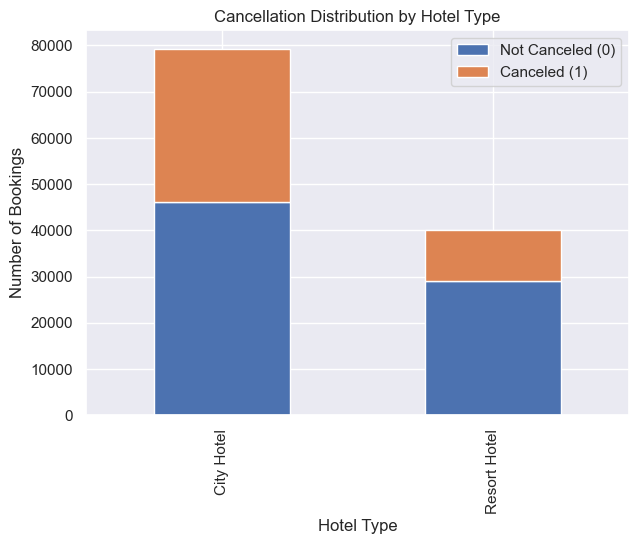

In [9]:
sns.set_style()
sns.set_theme(style='darkgrid')
data = df.groupby(['hotel', 'is_canceled']).size().unstack()

data.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title('Cancellation Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

City Hotels have significantly higher booking volume compared to Resort Hotels, indicating stronger demand in urban locations. However, they also show a much higher absolute number of cancellations (33,102 vs 11,122), which suggests that City Hotel bookings are more volatile and likely driven by flexible, short-term travel behavior. In contrast, Resort Hotels have relatively lower cancellations compared to their total bookings, indicating more stable and committed travel patterns, possibly due to leisure-based planning where trips are booked more deliberately.

When looking at cancellation rates, City Hotels not only dominate in volume but also appear to have a higher proportion of cancellations, reinforcing the idea that urban hotel demand is more sensitive to factors like last-minute changes, business travel uncertainty, and OTA-driven bookings. Resort Hotels, while smaller in scale, show comparatively better booking stability, suggesting stronger booking intent and lower cancellation risk per reservation.

Hotel is an important feature, but not a standalone “strong predictor.” It becomes meaningful in a comparative and interaction sense

## lead_time vs is_canceled

<Axes: xlabel='is_canceled', ylabel='lead_time'>

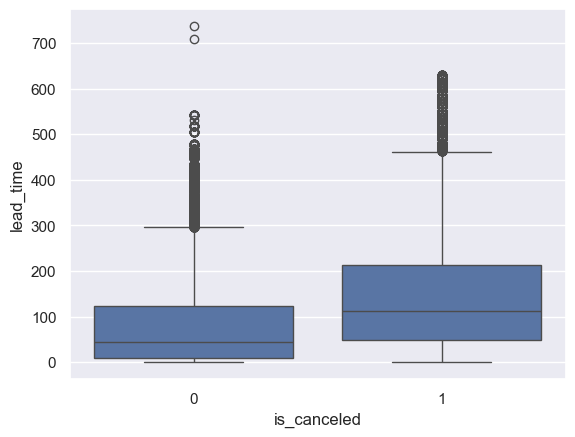

In [12]:
sns.boxplot(x='is_canceled',y='lead_time',data=df)

In [13]:
df.groupby([df['is_canceled'],df['hotel']])['lead_time'].agg(['min','max','mean','median','std','count'])

min  max        mean  median         std  count
is_canceled hotel                                                        
0           City Hotel      0  518   80.702734    50.0   89.863028  46228
            Resort Hotel    0  737   78.837618    38.0   93.057146  28938
1           City Hotel      0  629  150.281222   115.0  124.104915  33102
            Resort Hotel    0  471  128.680543   109.0   98.816173  11122

The bivariate analysis of `lead_time`, `hotel`, and `is_canceled` reveals one of the strongest cancellation patterns in the dataset. Customers who cancel bookings consistently show significantly higher lead times than those who complete their stays. In City Hotels, canceled bookings have an average lead time of approximately 150 days compared to around 81 days for non-canceled bookings, while Resort Hotels show a similar pattern with canceled bookings averaging nearly 129 days versus 79 days for retained bookings. Median values reinforce this trend, indicating that cancellations are strongly concentrated among customers who book far in advance. This suggests that longer planning horizons increase uncertainty, making customers more likely to modify or cancel reservations over time. Additionally, City Hotels exhibit higher cancellation-related lead times than Resort Hotels, supporting earlier findings that City Hotel bookings are more flexible and volatile. The extremely large standard deviations and high maximum values indicate a heavily right-skewed distribution with many long-term advance bookings and outliers. Overall, `lead_time` emerges as one of the most powerful predictors of cancellation behavior in the dataset and likely plays a central role in revenue management, overbooking strategy, and predictive modeling.


## arrival_date_year vs is_canceled

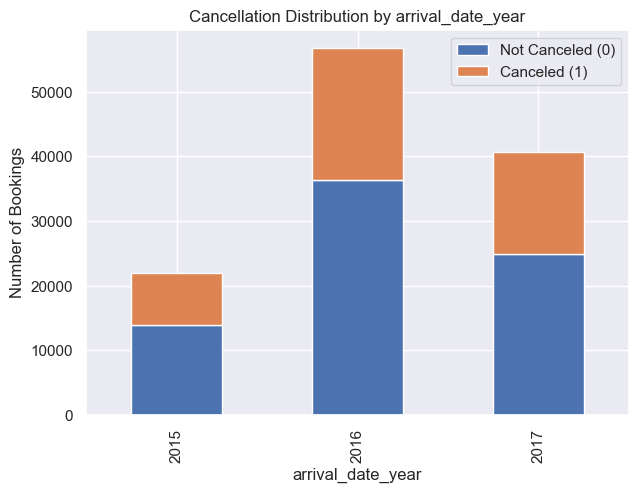

In [16]:
data = df.groupby(['arrival_date_year', 'is_canceled']).size().unstack()

data.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title('Cancellation Distribution by arrival_date_year')
plt.xlabel('arrival_date_year')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

In [17]:
data

is_canceled,0,1
arrival_date_year,,
2015,13854,8142
2016,36370,20337
2017,24942,15745


Arrival year shows higher absolute booking and cancellation counts in 2016, but this is primarily due to it being the only full-year dataset, while 2015 and 2017 contain partial-year data. When adjusted for this imbalance, there is no strong evidence of a structural change in cancellation behavior over time. Instead, cancellation patterns remain relatively stable across years, indicating that cancellations are driven more by customer characteristics and booking conditions than by temporal factors.

Arrival year is a weak predictive feature because it does not directly influence cancellation behavior and is heavily affected by data incompleteness across years. While it is useful for understanding temporal distribution and business trends, it does not provide meaningful separation between canceled and non-canceled bookings. Therefore, it should not be considered a key feature in predictive modeling.

## arrival_date_month vs is_canceled

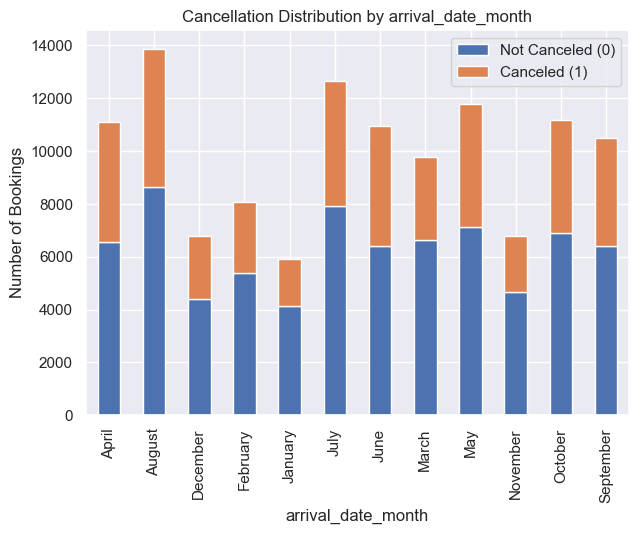

In [20]:
data = df.groupby(['arrival_date_month', 'is_canceled']).size().unstack()

data.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title('Cancellation Distribution by arrival_date_month')
plt.xlabel('arrival_date_month')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

In [21]:
data

is_canceled,0,1
arrival_date_month,,
April,6565,4524
August,8638,5239
December,4409,2371
February,5372,2696
January,4122,1807
July,7919,4742
June,6404,4535
March,6645,3149
May,7114,4677


Arrival month shows clear seasonal variation in booking volume, with peak activity during mid-year months such as July and August, and lower activity in winter months like January and February. However, cancellation behavior remains relatively proportional across all months, indicating that month primarily influences the volume of bookings rather than the likelihood of cancellation. As a result, arrival month provides weak predictive power for cancellation and is more useful for understanding seasonal demand patterns rather than modeling customer behavior.

Month = seasonality feature (contextual)
 Not a strong predictor of cancellation
 
 Useful for:

demand forecasting
time-based segmentation
business reporting

 Not useful as a primary ML feature alone

## arrival_date_week_number vs is_canceled

<Figure size 800x800 with 0 Axes>

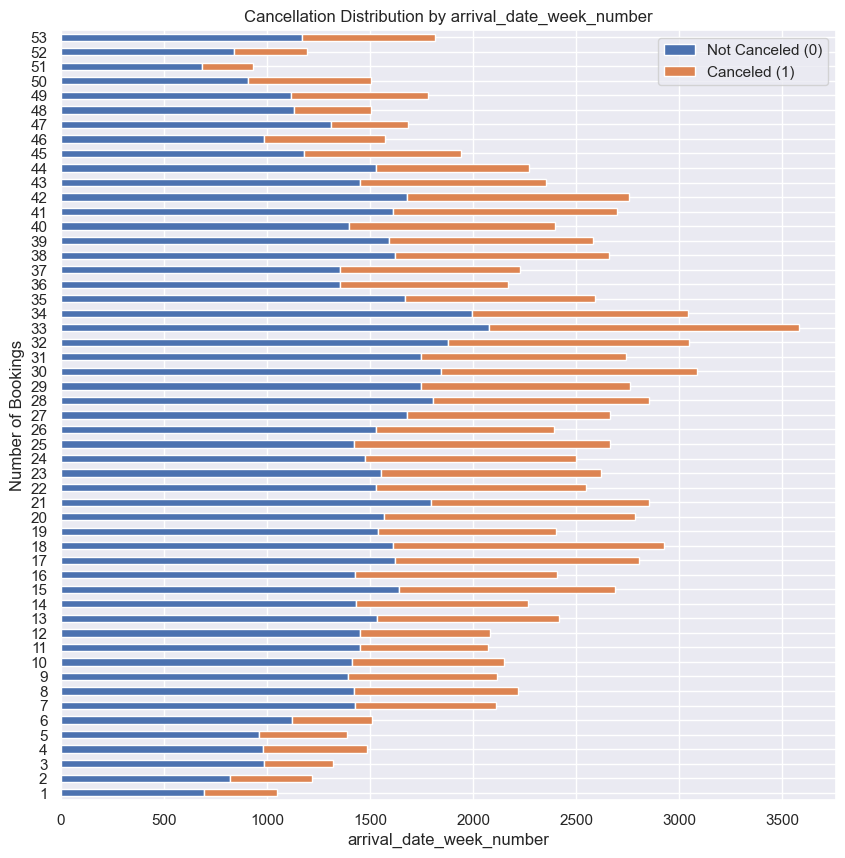

In [24]:
data = df.groupby(['arrival_date_week_number', 'is_canceled']).size().unstack()

plt.figure(figsize=(8,8))

data.plot(kind='barh', stacked=True, figsize=(10,10))

plt.title('Cancellation Distribution by arrival_date_week_number')
plt.xlabel('arrival_date_week_number')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

In [25]:
data

is_canceled,0,1
arrival_date_week_number,,
1,694,353
2,823,395
3,984,335
4,981,506
5,962,425
6,1123,385
7,1425,684
8,1423,793
9,1393,724


Arrival week number shows a clear seasonal demand cycle, with higher booking activity concentrated in mid-year weeks and lower activity at the beginning and end of the year. However, cancellation behavior closely follows booking volume without any significant deviation across weeks, indicating that weekly variation is driven by demand fluctuations rather than changes in customer cancellation behavior. As a result, arrival week number provides weak predictive power and is more useful for capturing seasonality trends than for modeling cancellation likelihood.

## stays_in_weekend_nights vs is_canceled

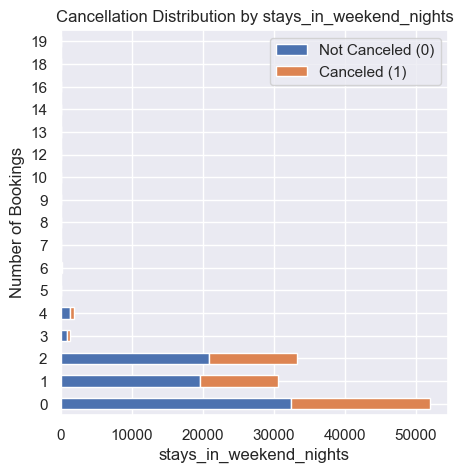

In [28]:
data = df.groupby(['stays_in_weekend_nights', 'is_canceled']).size().unstack()

data.plot(kind='barh', stacked=True, figsize=(5,5))

plt.title('Cancellation Distribution by stays_in_weekend_nights')
plt.xlabel('stays_in_weekend_nights')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

In [29]:
pd.crosstab([df['stays_in_weekend_nights'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                    0           1
stays_in_weekend_nights hotel                               
0                       City Hotel     57.014041   42.985959
                        Resort Hotel   77.117270   22.882730
1                       City Hotel     60.077447   39.922553
                        Resort Hotel   73.346388   26.653612
2                       City Hotel     59.333782   40.666218
                        Resort Hotel   66.919499   33.080501
3                       City Hotel     53.560372   46.439628
                        Resort Hotel   68.589744   31.410256
4                       City Hotel     38.047138   61.952862
                        Resort Hotel   73.427471   26.572529
5                       City Hotel     38.636364   61.363636
                        Resort Hotel   54.285714   45.714286
6                       City Hotel     20.000000   80.000000
                        Resort Hotel   51.327434   48.672566
7                       City Hotel      0.000000  100.000000
                        Resort Hotel   38.461538   61.538462
8                       City Hotel      8.333333   91.666667
                        Resort Hotel   66.666667   33.333333
9                       City Hotel     33.333333   66.666667
                        Resort Hotel   40.000000   60.000000
10                      City Hotel      0.000000  100.000000
                        Resort Hotel  100.000000    0.000000
12                      Resort Hotel   80.000000   20.000000
13                      City Hotel    100.000000    0.000000
                        Resort Hotel  100.000000    0.000000
14                      City Hotel    100.000000    0.000000
16                      City Hotel    100.000000    0.000000
                        Resort Hotel   50.000000   50.000000
18                      Resort Hotel  100.000000    0.000000
19                      Resort Hotel  100.000000    0.000000

Stays in weekend nights show that most hotel bookings are concentrated in short-duration stays of 0–2 nights, reflecting a dominance of short leisure trips. While cancellations follow similar proportional patterns across different stay lengths, there is no consistent trend indicating that longer or shorter weekend stays significantly influence cancellation behavior. Higher stay durations are sparse and irregular, making them unreliable for predictive modeling. Overall, weekend stay length has weak predictive power for cancellation and is better suited for describing customer travel patterns rather than explaining booking behavior

In [31]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## stays_in_week_nights vs is_canceled

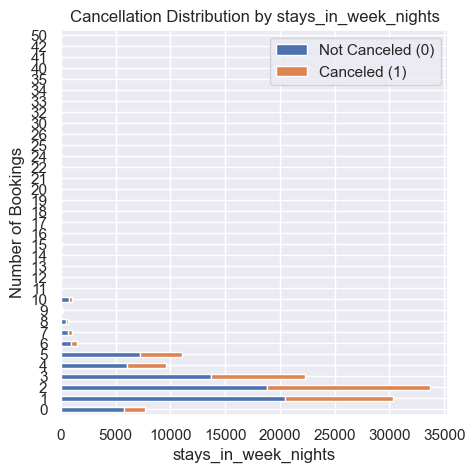

In [33]:
data = df.groupby(['stays_in_week_nights', 'is_canceled']).size().unstack()

data.plot(kind='barh', stacked=True, figsize=(5,5))

plt.title('Cancellation Distribution by stays_in_week_nights')
plt.xlabel('stays_in_week_nights')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled (0)', 'Canceled (1)'])
plt.show()

In [34]:
data

is_canceled,0,1
stays_in_week_nights,,
0,5732.0,1913.0
1,20479.0,9831.0
2,18810.0,14874.0
3,13753.0,8505.0
4,6068.0,3495.0
5,7216.0,3861.0
6,917.0,582.0
7,706.0,323.0
8,436.0,220.0


Stays in weekday nights show a strong concentration of bookings in short-duration stays, particularly between 1 and 4 nights, reflecting the dominance of business and short leisure travel. Cancellation patterns closely follow booking distributions across all stay durations, indicating no significant separation between canceled and non-canceled bookings based on stay length alone. Longer stays are rare and highly irregular, making them statistically unreliable and better treated as outliers. Overall, weekday stay duration provides weak predictive power and should be used primarily as a behavioral descriptor rather than a core predictive feature.

## adults vs is_canceled

<Axes: xlabel='is_canceled', ylabel='adults'>

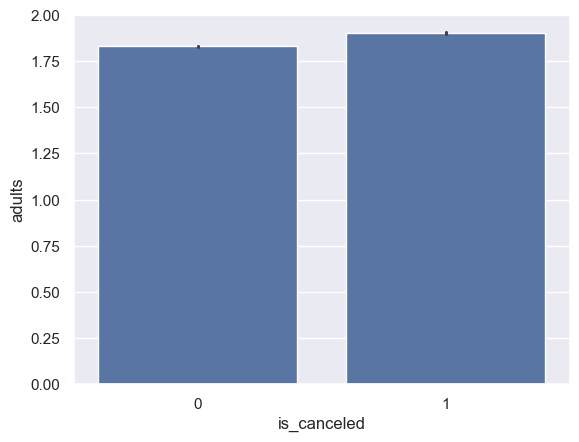

In [37]:
sns.barplot(x='is_canceled',y='adults',data=df)

In [38]:
df.groupby(['is_canceled','hotel'])['adults'].agg(['min','max','mean','median','std','count'])

min  max      mean  median       std  count
is_canceled hotel                                                    
0           City Hotel      0    4  1.828113     2.0  0.536068  46228
            Resort Hotel    0    4  1.832331     2.0  0.466616  28938
1           City Hotel      0    4  1.882907     2.0  0.467491  33102
            Resort Hotel    0   55  1.957741     2.0  1.083267  11122

The bivariate analysis of `adults`, `hotel`, and `is_canceled` shows that the number of adults has very limited influence on cancellation behavior. Across both City and Resort Hotels, the average number of adults remains highly consistent between canceled and non-canceled bookings, with means clustered close to 2 and medians fixed at 2 for all groups. This indicates that most hotel reservations are made by couples or two-person travelers regardless of cancellation outcome. Although canceled bookings show a marginally higher average adult count, the difference is too small to represent a meaningful behavioral signal. Resort Hotels exhibit a slightly larger standard deviation for canceled bookings due to the presence of extreme outliers, including a maximum value of 55 adults, which likely represents group reservations, bulk bookings, or data anomalies. Overall, the feature demonstrates very weak separation power and confirms earlier findings that demographic characteristics contribute far less to cancellation prediction than behavioral variables such as `lead_time`, `deposit_type`, and `market_segment`. While `adults` may still provide minor value when combined with other features like family composition or stay duration, it is not a strong standalone predictor of hotel booking cancellations.


## children vs is_canceled

<Axes: xlabel='is_canceled', ylabel='children'>

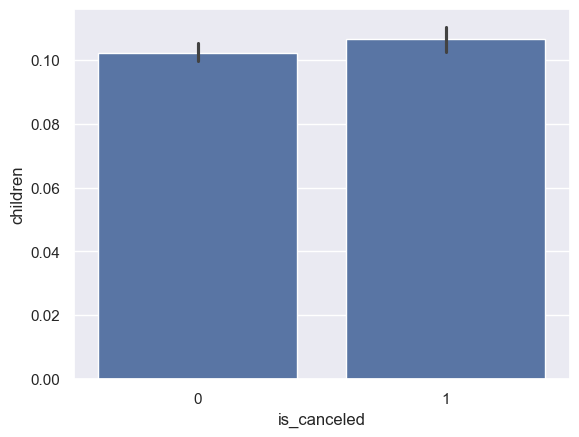

In [41]:
sns.barplot(x='is_canceled',y='children',data=df)

In [42]:
df.groupby('is_canceled')['children'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
is_canceled,,,,,,
0,0.0,3.0,0.102347,0.0,0.390836,75166
1,0.0,10.0,0.106513,0.0,0.411352,44220


The number of children shows extremely low average values across both canceled and non-canceled bookings, with medians at zero, indicating that most hotel reservations are made by adults without children. The distribution of children is nearly identical between both groups, suggesting that the presence of children does not significantly influence cancellation behavior. While a few extreme values exist in the canceled group, these are rare outliers and do not represent a general trend. Overall, the number of children is a very weak predictor of cancellation and has minimal impact on booking behavior.

## babies vs is_canceled

<Axes: xlabel='is_canceled', ylabel='babies'>

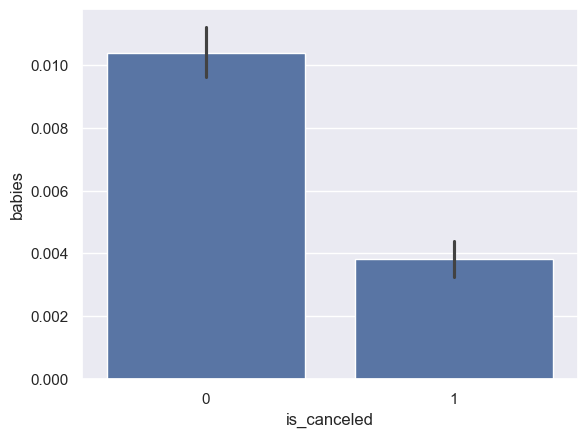

In [45]:
sns.barplot(x='is_canceled',y='babies',data=df)

In [46]:
df.groupby('is_canceled')['babies'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
is_canceled,,,,,,
0,0,10,0.010377,0.0,0.113007,75166
1,0,2,0.003821,0.0,0.062429,44224


Bookings involving babies appear to be:

extremely rare,
operationally insignificant in volume,
and weakly associated with cancellation behavior.

One possible behavioral interpretation is that families traveling with infants may have slightly more committed travel plans, leading to marginally lower cancellation tendencies. However, the signal is far too weak to draw strong conclusions.

In [48]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## meal vs is_canceled

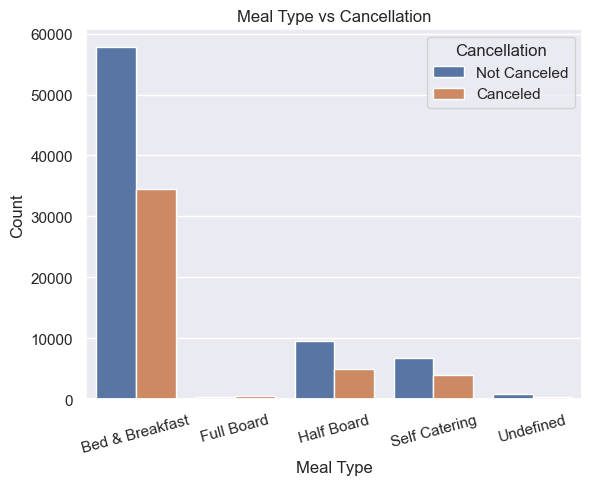

In [50]:
meal_map = {
    'BB': 'Bed & Breakfast',
    'HB': 'Half Board',
    'FB': 'Full Board',
    'SC': 'Self Catering',
    'Undefined': 'Undefined'
}

df['meal_full'] = df['meal'].map(meal_map)

sns.countplot(x='meal_full', data=df, hue='is_canceled')

plt.xticks(rotation=15)
plt.xlabel('Meal Type')
plt.ylabel('Count')
plt.title('Meal Type vs Cancellation')
plt.legend(title='Cancellation', labels=['Not Canceled', 'Canceled'])
plt.show()

In [51]:
pd.crosstab([df['meal'], df['hotel']], df['is_canceled'], normalize='index')*100

is_canceled                     0          1
meal      hotel                             
BB        City Hotel    57.199262  42.800738
          Resort Hotel  73.861023  26.138977
FB        City Hotel    20.454545  79.545455
          Resort Hotel  41.246684  58.753316
HB        City Hotel    62.022752  37.977248
          Resort Hotel  68.344519  31.655481
SC        City Hotel    62.485801  37.514199
          Resort Hotel  96.511628   3.488372
Undefined Resort Hotel  75.534645  24.465355

**1. BB (Bed & Breakfast) Dominates the Dataset**

BB is overwhelmingly the most common meal plan and mirrors the dataset’s overall cancellation behavior.

This suggests:

breakfast-inclusive plans are the industry standard,
customers prefer flexible and lower-commitment packages,
and meal selection alone is not a strong cancellation discriminator for mainstream bookings.

**2. FB (Full Board) Shows Exceptionally High Cancellation**

Full-board bookings exhibit a cancellation rate close to 60%, substantially higher than all other meal categories.

Possible explanations:

higher total booking cost,
longer vacation-oriented stays,
bookings made far in advance,
or customer uncertainty around premium package commitments.

However, sample size is relatively small (798 bookings), so conclusions should be interpreted cautiously.


**3. HB (Half Board) Has Slightly Lower Cancellation**

Half-board bookings show somewhat better retention behavior.

This may indicate:

more intentional travel planning,
resort/vacation travelers with stronger commitment,
or package travelers less likely to cancel spontaneously.

**4. Undefined Has the Lowest Cancellation Rate**

Bookings with undefined meal plans surprisingly show the lowest cancellation tendency.

This could reflect:

operational/default booking assignments,
corporate/internal bookings,
OTA processing quirks,
or incomplete data handling rather than true customer behavior.

This category may require further investigation during data cleaning or multivariate analysis.

**Business Interpretation**

Meal plan choice appears to partially reflect:

travel intent,
booking commitment level,
and package sensitivity.

Premium bundled plans (FB) may introduce greater cancellation risk due to higher financial commitment, while simpler plans (BB, SC) behave closer to normal booking patterns.

Modeling Insight

meal is a moderate-signal categorical feature:

stronger than demographic variables,
but weaker than high-impact behavioral features like lead_time, deposit_type, and market_segment.

## country vs is_canceled

In [54]:
pd.crosstab([df['country'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                    0           1
country hotel                               
ABW     City Hotel    100.000000    0.000000
AGO     City Hotel     41.420118   58.579882
        Resort Hotel   70.833333   29.166667
AIA     City Hotel    100.000000    0.000000
ALB     City Hotel     88.888889   11.111111
...                          ...         ...
ZAF     Resort Hotel   72.222222   27.777778
ZMB     City Hotel      0.000000  100.000000
        Resort Hotel  100.000000    0.000000
ZWE     City Hotel      0.000000  100.000000
        Resort Hotel  100.000000    0.000000

[291 rows x 2 columns]

In [55]:
# 1. Find the top 5 countries by total volume of bookings
top_5_countries = df['country'].value_counts().nlargest(5).index

# 2. Filter the dataframe to include only those top 5 countries
df_top_5 = df[df['country'].isin(top_5_countries)]

# 3. Run your exact crosstab code on the filtered dataframe
pd.crosstab([df_top_5['country'], df_top_5['hotel']],df_top_5['is_canceled'],normalize='index') * 100

is_canceled                   0          1
country hotel                             
DEU     City Hotel    82.380013  17.619987
        Resort Hotel  87.863674  12.136326
ESP     City Hotel    71.242681  28.757319
        Resort Hotel  78.493808  21.506192
FRA     City Hotel    80.429350  19.570650
        Resort Hotel  86.902545  13.097455
GBR     City Hotel    70.611477  29.388523
        Resort Hotel  86.923980  13.076020
PRT     City Hotel    35.138889  64.861111
        Resort Hotel  57.810550  42.189450

The bivariate analysis of `country`, `hotel`, and `is_canceled` reveals strong geographic and behavioral differences in cancellation patterns. A clear trend emerges where Resort Hotels consistently experience lower cancellation rates than City Hotels across all major countries, suggesting that leisure-oriented resort bookings are more committed and stable compared to flexible city travel. International travelers from countries like Germany (`DEU`), France (`FRA`), and the United Kingdom (`GBR`) show relatively low cancellation behavior, particularly in Resort Hotels where cancellation rates remain close to 12–13%. In contrast, Portuguese (`PRT`) customers exhibit exceptionally high cancellation rates, especially in City Hotels where nearly two-thirds of bookings are canceled. This indicates that domestic travelers are significantly more volatile and likely influenced by flexible booking behavior, OTA-driven reservations, or lower travel commitment. Overall, the analysis highlights that cancellation behavior is not driven by demographics alone but strongly depends on the interaction between customer geography, travel intent, and hotel type. These patterns identify domestic City Hotel bookings as a high-risk segment, while international Resort Hotel bookings emerge as the most reliable customer category.


## market_segment vs is_canceled

In [58]:
pd.crosstab([df['market_segment'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                          0           1
market_segment hotel                              
Aviation       City Hotel    78.059072   21.940928
Complementary  City Hotel    88.191882   11.808118
               Resort Hotel  83.582090   16.417910
Corporate      City Hotel    78.533155   21.466845
               Resort Hotel  84.798614   15.201386
Direct         City Hotel    82.668636   17.331364
               Resort Hotel  86.519269   13.480731
Groups         City Hotel    31.141324   68.858676
               Resort Hotel  57.607951   42.392049
Offline TA/TO  City Hotel    57.168448   42.831552
               Resort Hotel  84.769807   15.230193
Online TA      City Hotel    62.601941   37.398059
               Resort Hotel  64.758306   35.241694
Undefined      City Hotel     0.000000  100.000000

The bivariate analysis of `market_segment`, `hotel`, and `is_canceled` reveals some of the strongest behavioral patterns in the entire dataset. Cancellation behavior varies dramatically across booking channels and customer acquisition segments, confirming that the source of a reservation is a major determinant of booking reliability. Group bookings emerge as the riskiest segment, especially in City Hotels where nearly 69% of reservations are canceled, suggesting that large coordinated bookings are highly volatile and sensitive to schedule or planning changes. Offline TA/TO bookings also show elevated cancellation rates in City Hotels, highlighting the instability associated with intermediary-driven reservations. Online TA bookings display consistently high cancellation behavior across both hotel types, reinforcing the earlier insight that OTA-based customers tend to make more flexible or speculative bookings. In contrast, Direct, Corporate, Complementary, and Aviation segments exhibit significantly lower cancellation rates, indicating stronger customer commitment and more stable reservation behavior. Resort Hotels consistently outperform City Hotels across almost every market segment, further supporting the idea that leisure and destination travel involve higher booking commitment than urban or business-oriented stays. The `Undefined` segment showing 100% cancellation is likely a data-quality anomaly rather than a meaningful business pattern. Overall, this analysis identifies `market_segment` as one of the most powerful predictors of cancellation behavior and highlights how customer acquisition channels directly influence hotel revenue stability and operational risk.


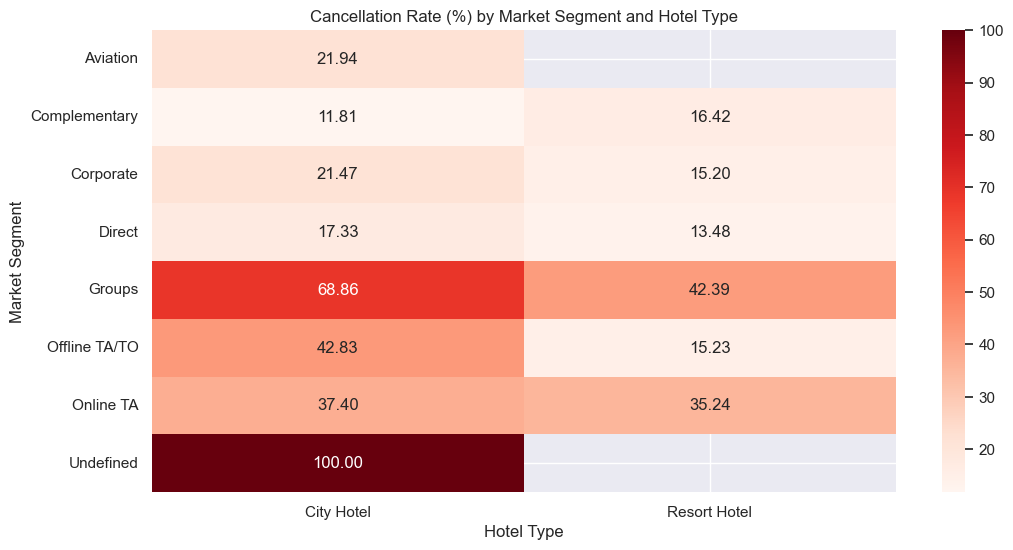

In [60]:
# Create cancellation percentage table
market_hotel_cancel = pd.crosstab(
    [df['market_segment'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Keep only cancellation percentage column
cancel_rates = market_hotel_cancel[1].unstack()

plt.figure(figsize=(12,6))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Cancellation Rate (%) by Market Segment and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Market Segment')

plt.show()

In [61]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'meal_full'],
      dtype='object')

## distribution_channel vs is_canceled

In [63]:
pd.crosstab([df['distribution_channel'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                 0           1
distribution_channel hotel                               
Corporate            City Hotel     76.936620   23.063380
                     Resort Hotel   78.953809   21.046191
Direct               City Hotel     81.828909   18.171091
                     Resort Hotel   83.153210   16.846790
GDS                  City Hotel     80.829016   19.170984
TA/TO                City Hotel     54.974255   45.025745
                     Resort Hotel   68.508211   31.491789
Undefined            City Hotel      0.000000  100.000000
                     Resort Hotel  100.000000    0.000000

The bivariate analysis of `distribution_channel`, `hotel`, and `is_canceled` reveals that booking source channels play a major role in determining cancellation behavior. TA/TO (Travel Agents/Tour Operators) bookings exhibit the highest cancellation rates across both hotel types, particularly in City Hotels where nearly 45% of reservations are canceled. This reinforces earlier findings that intermediary-driven bookings tend to be more flexible, speculative, and operationally volatile. Resort Hotels again demonstrate better booking stability than City Hotels within the same channel, indicating stronger travel commitment among leisure travelers. Direct bookings show substantially lower cancellation rates, suggesting that customers booking directly with hotels are more reliable and less likely to cancel. Corporate and GDS channels also maintain relatively stable cancellation behavior, reflecting structured business travel patterns and more predictable booking intent. The `Undefined` category displays extreme outcomes due to very small sample sizes and likely represents data anomalies rather than meaningful operational behavior. Overall, the analysis highlights that customer acquisition channels significantly influence revenue stability and confirms that OTA/intermediary dependence increases cancellation risk, especially for City Hotels. This makes `distribution_channel` an important behavioral feature for both predictive modeling and hotel revenue-management strategy.


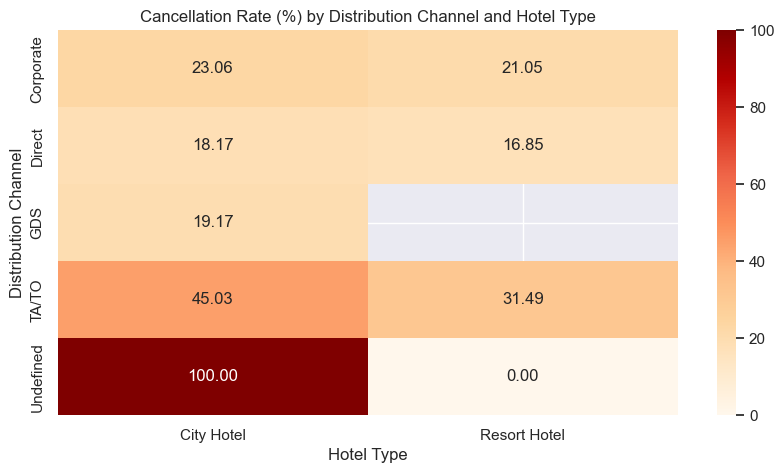

In [65]:
# Create percentage table
dist_cancel = pd.crosstab(
    [df['distribution_channel'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentages
cancel_rates = dist_cancel[1].unstack()

plt.figure(figsize=(10,5))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.2f',
    cmap='OrRd'
)

plt.title('Cancellation Rate (%) by Distribution Channel and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Distribution Channel')

plt.show()

## is_repeated_guest vs is_canceled

In [67]:
pd.crosstab([df['is_repeated_guest'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                             0          1
is_repeated_guest hotel                             
0                 City Hotel    57.746643  42.253357
                  Resort Hotel  71.237135  28.762865
1                 City Hotel    78.297244  21.702756
                  Resort Hotel  93.757030   6.242970

The bivariate analysis of is_repeated_guest, hotel, and is_canceled reveals a very strong loyalty-driven behavioral pattern in hotel cancellations. Repeated guests consistently show significantly lower cancellation rates compared to first-time customers across both hotel types, indicating that customer loyalty strongly improves booking reliability. In City Hotels, cancellation rates drop from approximately 42% among new guests to around 22% for repeated guests, while Resort Hotels show an even stronger effect, with repeated guests exhibiting an exceptionally low cancellation rate of nearly 6%. This suggests that loyal customers are far more committed to their travel plans and less likely to make speculative or flexible reservations. Resort Hotels particularly benefit from repeat customers, reinforcing the idea that leisure and destination-based travel fosters stronger long-term customer relationships and booking commitment. In contrast, first-time guests—especially in City Hotels—represent a much more volatile segment with substantially higher operational risk. Overall, this analysis identifies guest loyalty as a highly valuable predictor of cancellation behavior and highlights the business importance of customer retention strategies, loyalty programs, and repeat-booking incentives.

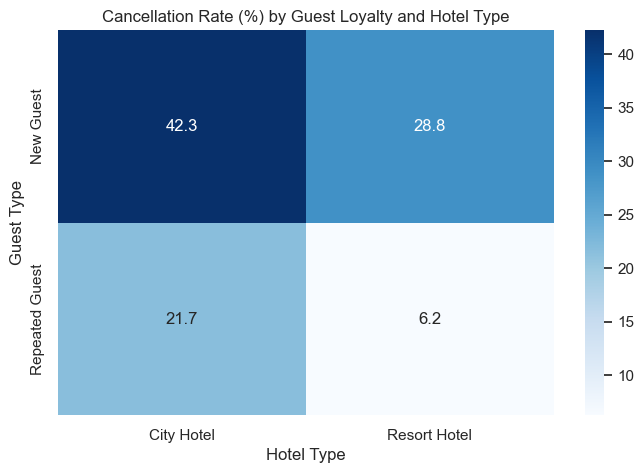

In [69]:
# Create cancellation percentage table
repeat_cancel = pd.crosstab(
    [df['is_repeated_guest'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentages
cancel_rates = repeat_cancel[1].unstack()

# Rename index labels for readability
cancel_rates.index = ['New Guest', 'Repeated Guest']

plt.figure(figsize=(8,5))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Cancellation Rate (%) by Guest Loyalty and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Guest Type')

plt.show()

## previous_cancellations vs is_canceled

In [71]:
pd.crosstab([df['previous_cancellations'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                  0           1
previous_cancellations hotel                              
0                      City Hotel    62.018366   37.981634
                       Resort Hotel  73.827794   26.172206
1                      City Hotel     3.705141   96.294859
                       Resort Hotel  16.294643   83.705357
2                      City Hotel    81.944444   18.055556
                       Resort Hotel  43.181818   56.818182
3                      City Hotel    86.274510   13.725490
                       Resort Hotel   7.142857   92.857143
4                      City Hotel    84.000000   16.000000
                       Resort Hotel  50.000000   50.000000
5                      City Hotel    93.750000    6.250000
                       Resort Hotel  66.666667   33.333333
6                      City Hotel    68.181818   31.818182
11                     City Hotel    71.428571   28.571429
13                     City Hotel     8.333333   91.666667
14                     Resort Hotel   0.000000  100.000000
19                     Resort Hotel   0.000000  100.000000
21                     City Hotel     0.000000  100.000000
24                     Resort Hotel   0.000000  100.000000
25                     Resort Hotel   0.000000  100.000000
26                     Resort Hotel   0.000000  100.000000

The bivariate analysis of previous_cancellations, hotel, and is_canceled reveals one of the strongest behavioral signals in the dataset: customers with a history of cancellations are dramatically more likely to cancel again. Guests with zero previous cancellations already show moderate cancellation behavior, particularly in City Hotels, but once a customer has even one prior cancellation, the probability of cancellation rises sharply to extremely high levels. For example, customers with one previous cancellation exhibit cancellation rates above 96% in City Hotels and nearly 84% in Resort Hotels. This strongly suggests the presence of habitual cancellation behavior and indicates that past booking actions are highly predictive of future booking reliability. Although higher counts of previous cancellations contain smaller sample sizes and show some fluctuations, the overall trend consistently points toward elevated cancellation risk among historically unreliable customers. Resort Hotels generally maintain slightly lower cancellation rates than City Hotels, but the effect of prior cancellation history remains dominant across both hotel types. Extreme values such as 100% cancellation for very high previous-cancellation counts are likely caused by very small sample sizes and should be interpreted cautiously. Overall, previous_cancellations emerges as a critical predictive feature for cancellation modeling and provides valuable business insight for risk scoring, deposit policy design, and customer segmentation strategies.

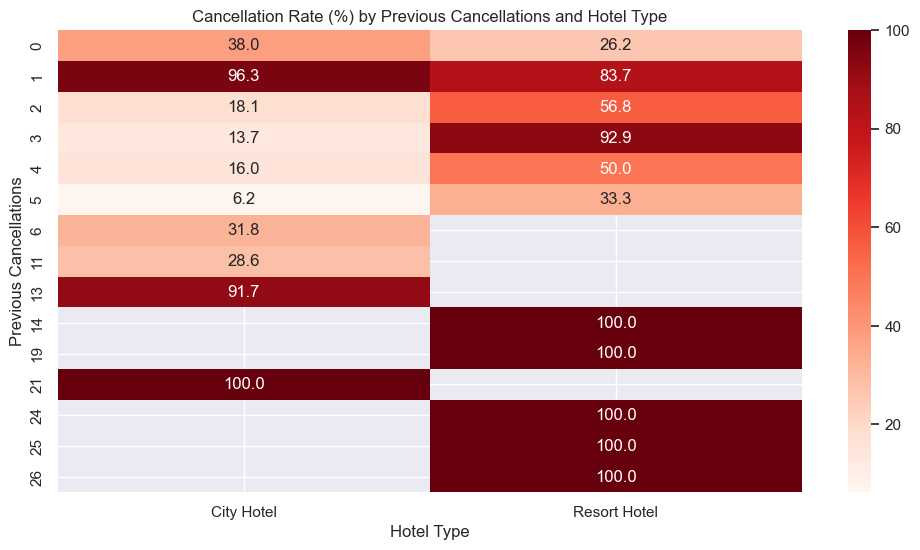

In [73]:
# Create cancellation percentage table
prev_cancel = pd.crosstab(
    [df['previous_cancellations'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentage column
cancel_rates = prev_cancel[1].unstack()

plt.figure(figsize=(12,6))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Cancellation Rate (%) by Previous Cancellations and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Previous Cancellations')

plt.show()

In [74]:
df.columns


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'meal_full'],
      dtype='object')

## previous_bookings_not_canceled vs is_canceled

In [76]:
pd.crosstab([df['previous_bookings_not_canceled'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                           0          1
previous_bookings_not_canceled hotel                              
0                              City Hotel     57.576342  42.423658
                               Resort Hotel   70.960871  29.039129
1                              City Hotel     92.091388   7.908612
                               Resort Hotel   96.505653   3.494347
2                              City Hotel     93.750000   6.250000
...                                                 ...        ...
68                             City Hotel    100.000000   0.000000
69                             City Hotel    100.000000   0.000000
70                             City Hotel    100.000000   0.000000
71                             City Hotel    100.000000   0.000000
72                             City Hotel    100.000000   0.000000

[104 rows x 2 columns]

The bivariate analysis of previous_bookings_not_canceled, hotel, and is_canceled reveals a powerful customer loyalty and reliability pattern. Guests with no prior successful bookings show relatively high cancellation rates, especially in City Hotels where more than 42% of reservations are canceled. However, once a customer has even one previously completed booking, cancellation probability drops dramatically across both hotel types. Customers with one successful prior booking show cancellation rates below 8% in City Hotels and below 4% in Resort Hotels, indicating that historically reliable guests are far more likely to honor future reservations. As the number of successful previous bookings increases, cancellation rates continue to remain extremely low, with many high-frequency returning customers exhibiting near-zero cancellation behavior. This demonstrates strong behavioral consistency and highlights that positive booking history is one of the clearest indicators of customer reliability in the dataset. Resort Hotels again display stronger booking stability than City Hotels, but the dominant pattern is driven by customer history rather than hotel type alone. Extremely high values showing 100% retention at large booking counts are likely influenced by small sample sizes but still reinforce the broader trend of loyal-customer stability. Overall, previous_bookings_not_canceled emerges as one of the most valuable predictive features in the dataset and provides important business insight for customer segmentation, loyalty programs, targeted retention strategies, and cancellation-risk modeling.

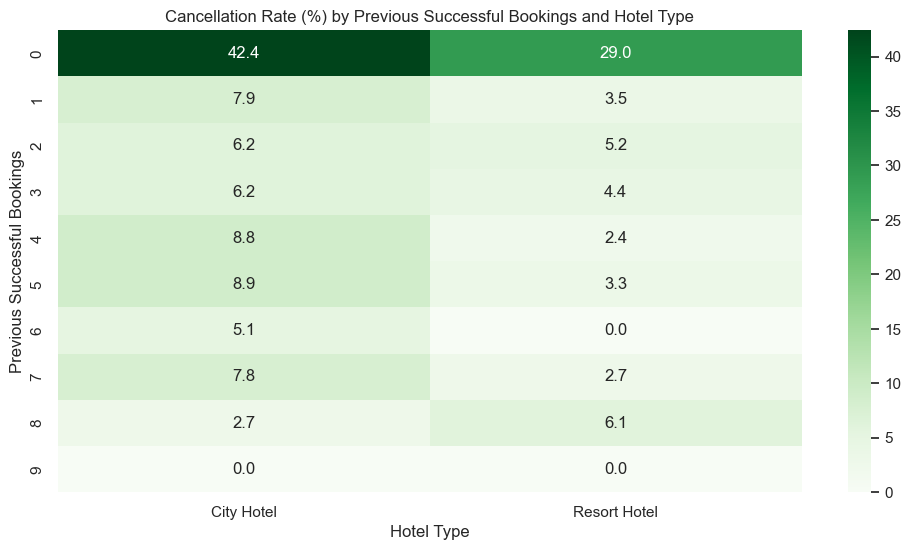

In [78]:
# Create cancellation percentage table
prev_success = pd.crosstab(
    [df['previous_bookings_not_canceled'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentage
cancel_rates = prev_success[1].unstack()

# Optional: limit to first 10 booking counts for readability
cancel_rates = cancel_rates.head(10)

plt.figure(figsize=(12,6))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.1f',
    cmap='Greens'
)

plt.title('Cancellation Rate (%) by Previous Successful Bookings and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Previous Successful Bookings')

plt.show()

## reserved_room_type vs is_canceled

In [80]:
pd.crosstab([df['reserved_room_type'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                               0           1
reserved_room_type hotel                               
A                  City Hotel     56.469367   43.530633
                   Resort Hotel   72.725330   27.274670
B                  City Hotel     66.995516   33.004484
                   Resort Hotel  100.000000    0.000000
C                  City Hotel     64.285714   35.714286
                   Resort Hotel   66.993464   33.006536
D                  City Hotel     64.760367   35.239633
                   Resort Hotel   73.698372   26.301628
E                  City Hotel     67.482292   32.517708
                   Resort Hotel   71.718185   28.281815
F                  City Hotel     60.915690   39.084310
                   Resort Hotel   83.725136   16.274864
G                  City Hotel     75.413223   24.586777
                   Resort Hotel   60.000000   40.000000
H                  Resort Hotel   59.234609   40.765391
L                  Resort Hotel   66.666667   33.333333
P                  City Hotel      0.000000  100.000000
                   Resort Hotel    0.000000  100.000000

The bivariate analysis of reserved_room_type, hotel, and is_canceled shows that room preferences are moderately associated with cancellation behavior, though the impact is weaker than major behavioral features such as lead_time or market_segment. Across most room categories, Resort Hotels consistently exhibit lower cancellation rates than City Hotels, reinforcing the broader pattern that leisure-oriented resort bookings are generally more stable and committed. Standard room types such as A, D, and E account for the majority of reservations and display cancellation behavior close to the dataset average, with City Hotels showing noticeably higher volatility. Certain premium or less common room categories display elevated cancellation rates, particularly room types F, G, and H, which may indicate that higher-cost or specialized room bookings are more prone to plan changes and speculative reservations. The extreme 100% cancellation observed for room type P is likely due to extremely small sample sizes or operational anomalies rather than meaningful customer behavior. Similarly, categories with perfect retention or highly fluctuating percentages should be interpreted cautiously because of limited observations. Overall, the analysis suggests that room type contributes some behavioral signal related to pricing, booking intent, and customer commitment, but its predictive strength is moderate compared to stronger cancellation drivers. Room-category interactions with ADR, hotel type, and market segment may provide more meaningful insights during multivariate analysis.

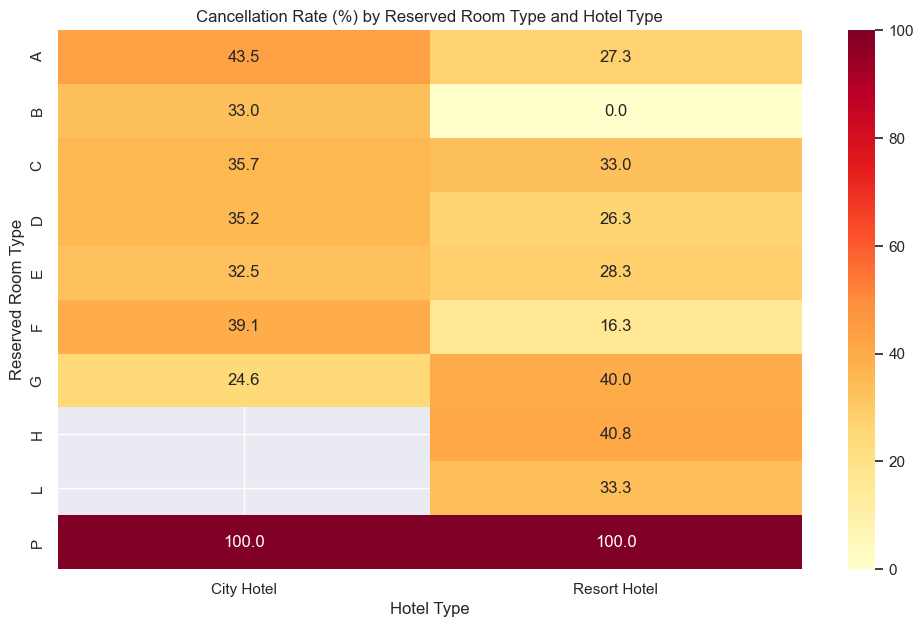

In [82]:
# Create cancellation percentage table
room_cancel = pd.crosstab(
    [df['reserved_room_type'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentages
cancel_rates = room_cancel[1].unstack()

plt.figure(figsize=(12,7))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate (%) by Reserved Room Type and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Reserved Room Type')

plt.show()

## assigned_room_type vs is_canceled

In [84]:
pd.crosstab([df['assigned_room_type'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                              0           1
assigned_room_type hotel                              
A                  City Hotel    52.811058   47.188942
                   Resort Hotel  64.525402   35.474598
B                  City Hotel    74.900200   25.099800
                   Resort Hotel  94.339623    5.660377
C                  City Hotel    90.683230    9.316770
                   Resort Hotel  80.532972   19.467028
D                  City Hotel    71.481012   28.518988
                   Resort Hotel  79.794951   20.205049
E                  City Hotel    75.092251   24.907749
                   Resort Hotel  74.671869   25.328131
F                  City Hotel    64.370664   35.629336
                   Resort Hotel  87.997692   12.002308
G                  City Hotel    81.571429   18.428571
                   Resort Hotel  64.867782   35.132218
H                  Resort Hotel  64.747191   35.252809
I                  Resort Hotel  98.622590    1.377410
K                  City Hotel    95.698925    4.301075
L                  Resort Hotel   0.000000  100.000000
P                  City Hotel     0.000000  100.000000
                   Resort Hotel   0.000000  100.000000

The bivariate analysis of assigned_room_type, hotel, and is_canceled reveals stronger behavioral variation than the reserved room analysis, suggesting that the final room allocation may better capture operational and customer commitment patterns. City Hotels consistently experience higher cancellation rates across most assigned room categories, reaffirming their more volatile booking behavior compared to Resort Hotels. Standard room type A, which likely represents the most frequently allocated category, shows particularly high cancellation rates, especially in City Hotels where nearly half the bookings are canceled. In contrast, several upgraded or premium assigned room types such as C, I, and K exhibit extremely low cancellation rates, indicating that customers receiving higher-value or specialized room allocations tend to be much more committed to their stays. Resort Hotels again demonstrate stronger booking stability across most room categories, especially for room types B, F, and I. Certain categories like L and P show 100% cancellation, but these are likely driven by extremely small sample sizes or operational anomalies rather than meaningful customer behavior. Overall, assigned room type appears to contain useful operational and behavioral information related to booking reliability, customer satisfaction, and potential room upgrades. The stronger separation observed here compared to reserved room types suggests that final room assignment may indirectly reflect hotel operational decisions, customer value, or upgrade handling, making it a potentially informative feature for predictive modeling and customer segmentation.

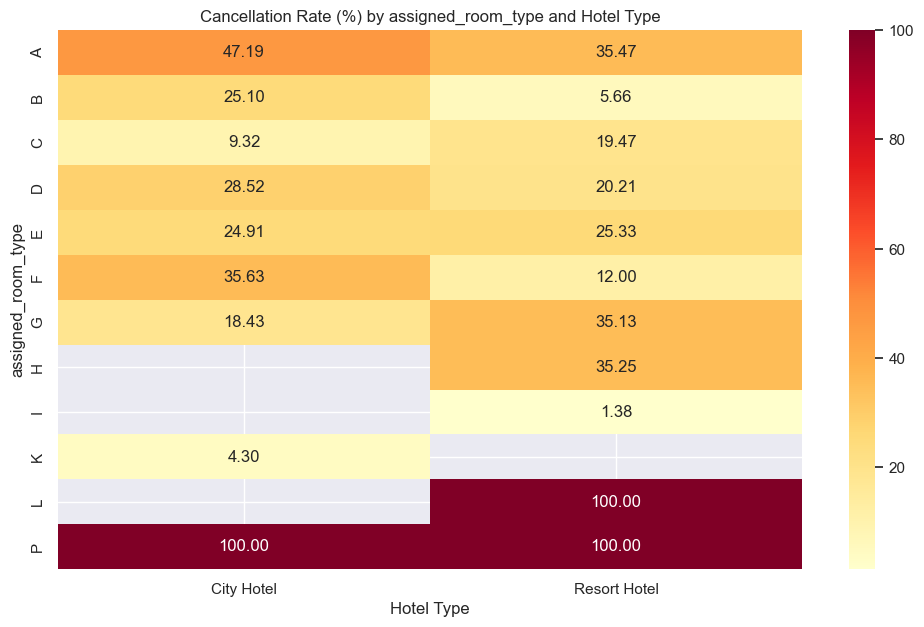

In [86]:
# Create cancellation percentage table
room_cancel = pd.crosstab(
    [df['assigned_room_type'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

# Extract cancellation percentages
cancel_rates = room_cancel[1].unstack()

plt.figure(figsize=(12,7))

sns.heatmap(
    cancel_rates,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate (%) by assigned_room_type and Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('assigned_room_type')

plt.show()

In [133]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'meal_full'],
      dtype='object')

## booking_changes vs is_canceled

In [136]:
pd.crosstab([df['booking_changes'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                            0           1
booking_changes hotel                               
0               City Hotel     54.500304   45.499696
                Resort Hotel   69.093390   30.906610
1               City Hotel     86.255531   13.744469
                Resort Hotel   85.134394   14.865606
2               City Hotel     76.336898   23.663102
                Resort Hotel   84.945548   15.054452
3               City Hotel     81.370450   18.629550
                Resort Hotel   87.608696   12.391304
4               City Hotel     79.381443   20.618557
                Resort Hotel   85.164835   14.835165
5               City Hotel     73.913043   26.086957
                Resort Hotel   88.888889   11.111111
6               City Hotel     67.741935   32.258065
                Resort Hotel   75.000000   25.000000
7               City Hotel     94.736842    5.263158
                Resort Hotel   83.333333   16.666667
8               City Hotel     77.777778   22.222222
                Resort Hotel   75.000000   25.000000
9               City Hotel     75.000000   25.000000
                Resort Hotel  100.000000    0.000000
10              City Hotel    100.000000    0.000000
                Resort Hotel   66.666667   33.333333
11              City Hotel    100.000000    0.000000
12              City Hotel    100.000000    0.000000
                Resort Hotel  100.000000    0.000000
13              City Hotel    100.000000    0.000000
                Resort Hotel  100.000000    0.000000
14              City Hotel     80.000000   20.000000
15              City Hotel    100.000000    0.000000
16              City Hotel    100.000000    0.000000
                Resort Hotel    0.000000  100.000000
17              City Hotel    100.000000    0.000000
                Resort Hotel  100.000000    0.000000
18              City Hotel    100.000000    0.000000
20              City Hotel    100.000000    0.000000
21              City Hotel    100.000000    0.000000

The relationship between booking_changes and is_canceled reveals a strong behavioral pattern associated with customer commitment and booking stability. Reservations with zero booking changes exhibit the highest cancellation rates, particularly in City Hotel where nearly 45.5% of bookings are canceled, compared to about 30.9% in Resort Hotels. However, once customers make even one modification to their reservation, cancellation rates drop sharply to nearly 13–15% across both hotel types. This suggests that customers who actively modify bookings are generally more engaged and committed to completing their stay. Across higher numbers of booking changes, cancellation rates remain relatively lower and stable, although fluctuations appear in extreme values due to very small sample sizes. Overall, booking_changes behaves as a meaningful behavioral signal: bookings with no changes are substantially more volatile, while modified reservations tend to indicate stronger booking intent and reduced cancellation probability. The effect is especially pronounced for City Hotels, which consistently show higher cancellation tendencies than Resort Hotels.

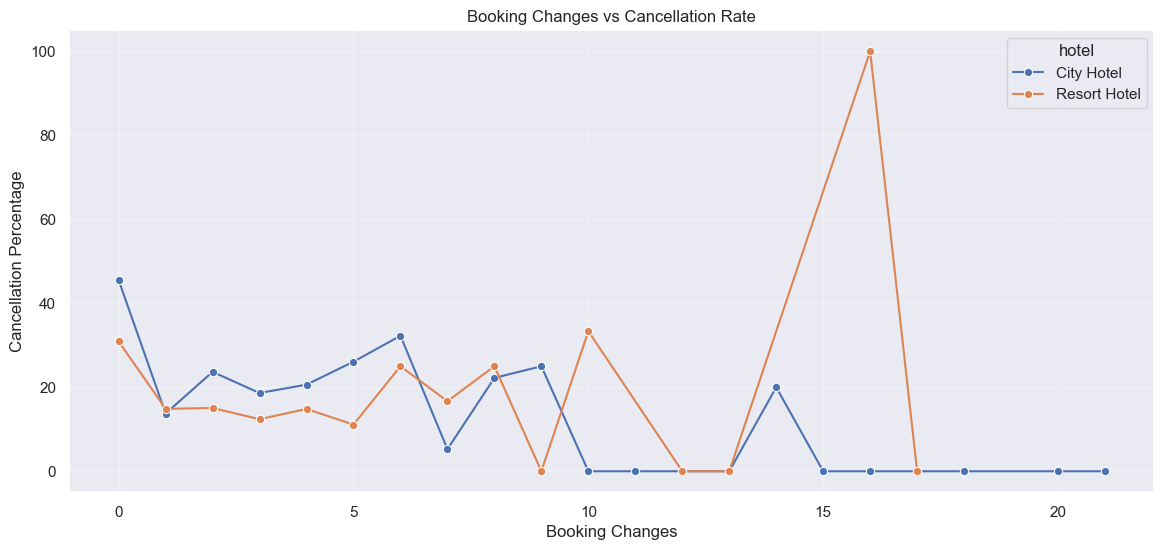

In [139]:
booking_change_cancel = pd.crosstab(
    [df['booking_changes'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

booking_change_cancel = booking_change_cancel.reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=booking_change_cancel,
    x='booking_changes',
    y=1,
    hue='hotel',
    marker='o'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Booking Changes')
plt.title('Booking Changes vs Cancellation Rate')
plt.grid(alpha=0.3)

plt.show()

## deposit_type vs is_canceled

In [142]:
pd.crosstab([df['deposit_type'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                        0          1
deposit_type hotel                             
No Deposit   City Hotel    69.531321  30.468679
             Resort Hotel  75.261132  24.738868
Non Refund   City Hotel     0.186509  99.813491
             Resort Hotel   4.013962  95.986038
Refundable   City Hotel    30.000000  70.000000
             Resort Hotel  84.507042  15.492958

The relationship between deposit_type and is_canceled is one of the strongest behavioral patterns observed in the hotel booking dataset. Bookings with Non Refund deposits exhibit extremely high cancellation rates, reaching nearly 100% in both City Hotel and Resort Hotels. This counterintuitive pattern suggests that non-refundable deposits are likely imposed on already high-risk reservations, rather than preventing cancellations themselves. In contrast, bookings with No Deposit show comparatively lower but still substantial cancellation rates, with City Hotels again demonstrating higher volatility than Resort Hotels. The Refundable category presents mixed behavior: City Hotels show elevated cancellation tendencies, while Resort Hotels appear relatively stable. Overall, deposit policy emerges as a highly predictive feature for cancellation modeling, indicating strong interactions between customer commitment, booking risk, and hotel revenue management strategies. The findings also reinforce the broader trend that City Hotel reservations are consistently more cancellation-prone than Resort Hotel bookings.

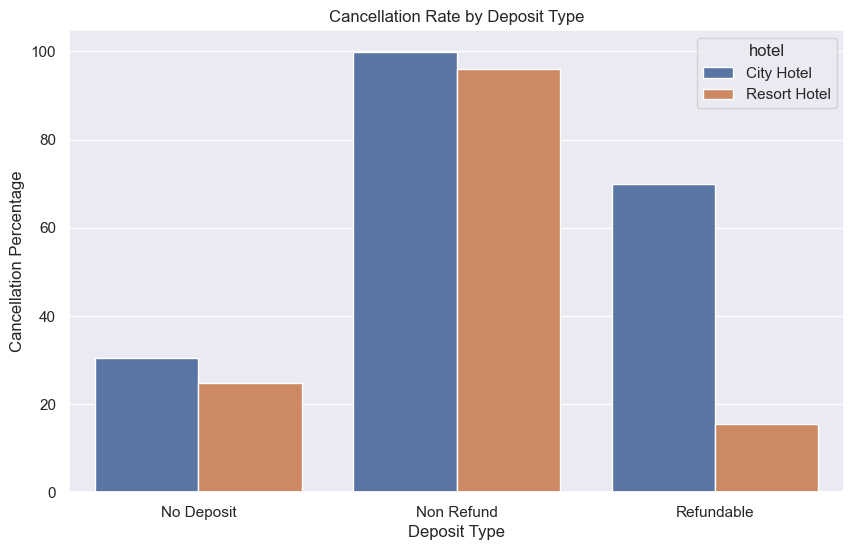

In [177]:
deposit_cancel = pd.crosstab(
    [df['deposit_type'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

deposit_cancel = deposit_cancel.reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=deposit_cancel,
    x='deposit_type',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Deposit Type')
plt.title('Cancellation Rate by Deposit Type')

plt.show()

## agent vs is_canceled

In [148]:
pd.crosstab([df['agent'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                  0          1
agent hotel                              
1.0   City Hotel     26.719910  73.280090
      Resort Hotel    7.407407  92.592593
2.0   City Hotel     55.000000  45.000000
      Resort Hotel   93.137255   6.862745
3.0   City Hotel     41.360856  58.639144
...                        ...        ...
510.0 Resort Hotel  100.000000   0.000000
526.0 Resort Hotel   90.000000  10.000000
527.0 Resort Hotel  100.000000   0.000000
531.0 Resort Hotel   32.352941  67.647059
535.0 Resort Hotel  100.000000   0.000000

[408 rows x 2 columns]

The relationship between agent and is_canceled highlights the significant influence of travel intermediaries on booking behavior and cancellation risk. The analysis reveals substantial variation in cancellation rates across different agents, indicating that some intermediaries consistently generate more reliable bookings while others are associated with highly volatile reservation patterns. Several agents exhibit extremely high cancellation rates, in some cases exceeding 70–90%, while others maintain relatively stable booking behavior with low cancellation proportions. This variability suggests that the quality of customer acquisition, booking intent, pricing policies, and cancellation flexibility differ considerably across agents. The effect is particularly important because the hotel booking dataset is heavily dependent on OTA and travel-agent channels, making intermediary behavior a major operational and revenue-management factor. Due to the very high cardinality of the agent feature and the presence of many low-frequency agents, extreme percentages for certain IDs are likely influenced by small sample sizes. Nevertheless, the analysis confirms that agent is a high-signal categorical feature and could provide strong predictive value after proper encoding or aggregation.

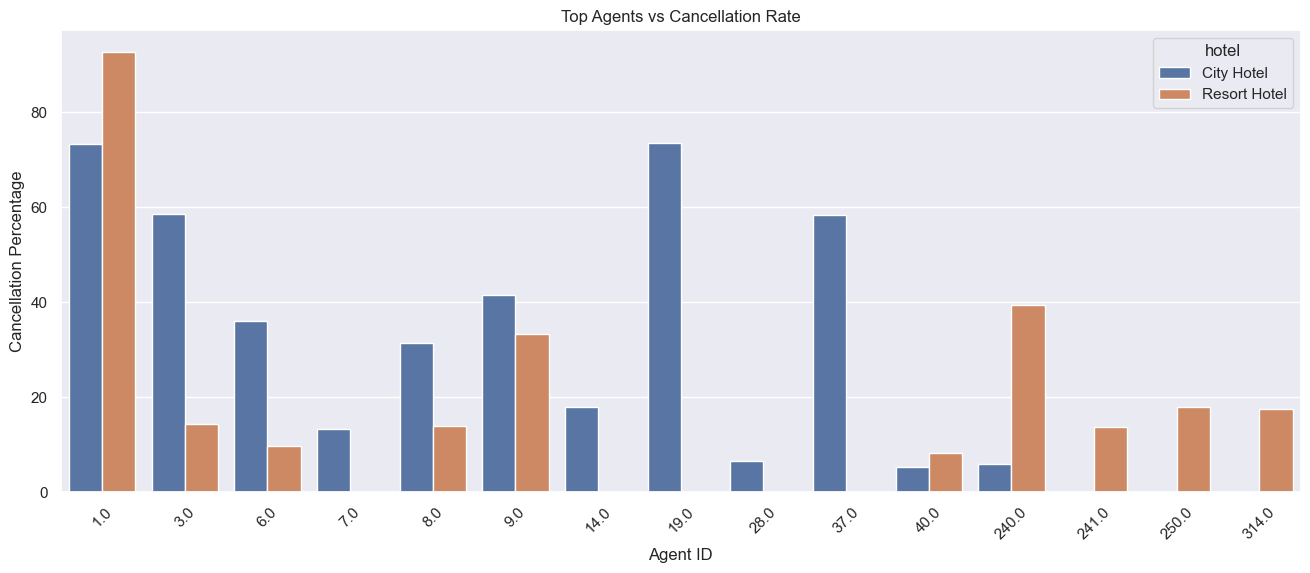

In [151]:
top_agents = df['agent'].value_counts().head(15).index

temp = df[df['agent'].isin(top_agents)]

agent_cancel = pd.crosstab(
    [temp['agent'], temp['hotel']],
    temp['is_canceled'],
    normalize='index'
) * 100

agent_cancel = agent_cancel.reset_index()

plt.figure(figsize=(16,6))

sns.barplot(
    data=agent_cancel,
    x='agent',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Agent ID')
plt.title('Top Agents vs Cancellation Rate')

plt.xticks(rotation=45)

plt.show()

In [153]:
# Top 15 agents by booking volume
top_agents = df['agent'].value_counts().head(15).index

# Filter dataset
temp = df[df['agent'].isin(top_agents)]

# Numerical cancellation summary
agent_summary = pd.crosstab(
    [temp['agent'], temp['hotel']],
    temp['is_canceled'],
    normalize='index'
) * 100

# Rename columns
agent_summary.columns = ['Not_Canceled_%', 'Canceled_%']

# Add booking counts
booking_counts = temp.groupby(['agent', 'hotel']).size()

# Final summary table
agent_summary['Total_Bookings'] = booking_counts

# Reset index for cleaner display
agent_summary = agent_summary.reset_index()

# Sort by cancellation percentage
agent_summary = agent_summary.sort_values(
    by='Canceled_%',
    ascending=False
)

agent_summary

,agent,hotel,Not_Canceled_%,Canceled_%,Total_Bookings
1,1.0,Resort Hotel,7.407407,92.592593,54
12,19.0,City Hotel,26.484449,73.515551,1061
0,1.0,City Hotel,26.719910,73.280090,7137
2,3.0,City Hotel,41.360856,58.639144,1308
14,37.0,City Hotel,41.707317,58.292683,1230
9,9.0,City Hotel,58.497888,41.502112,31955
18,240.0,Resort Hotel,60.568141,39.431859,13905
4,6.0,City Hotel,63.995527,36.004473,2683
10,9.0,Resort Hotel,66.666667,33.333333,6
7,8.0,City Hotel,68.608414,31.391586,1236


Top Agents vs Cancellation — Bivariate Analysis Summary

Analysis of the top booking agents reveals significant differences in cancellation behavior across major intermediaries. Some high-volume agents are associated with substantially elevated cancellation rates, indicating that booking reliability varies considerably depending on the travel intermediary involved. Certain agents generate highly volatile reservations with cancellation rates exceeding 70–90%, while others contribute comparatively stable and reliable bookings. These patterns suggest that agent-specific factors such as customer profile, booking flexibility, pricing strategies, and OTA policies strongly influence cancellation outcomes. Since top agents account for a major share of overall hotel demand, their behavior has direct implications for occupancy management, revenue forecasting, and cancellation prediction. Overall, the findings confirm that agent-based booking channels are a critical operational driver, and top agents should be treated as highly informative features during predictive modeling and feature engineering.

In [156]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'meal_full'],
      dtype='object')

## company vs is_canceled

In [159]:
pd.crosstab([df['company'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                    0           1
company hotel                               
6.0     Resort Hotel  100.000000    0.000000
8.0     City Hotel    100.000000    0.000000
9.0     City Hotel     93.333333    6.666667
        Resort Hotel   90.909091    9.090909
10.0    Resort Hotel  100.000000    0.000000
...                          ...         ...
531.0   Resort Hotel    0.000000  100.000000
534.0   Resort Hotel  100.000000    0.000000
539.0   Resort Hotel  100.000000    0.000000
541.0   Resort Hotel  100.000000    0.000000
543.0   Resort Hotel    0.000000  100.000000

[442 rows x 2 columns]

### Finding top 10 Companies

In [161]:
# Top 10 companies by booking volume
top_companies = df['company'].value_counts().head(10).index

# Filter dataframe
temp = df[df['company'].isin(top_companies)]

# Crosstab for cancellation percentages
pd.crosstab(
    [temp['company'], temp['hotel']],
    temp['is_canceled'],
    normalize='index'
) * 100

is_canceled                    0          1
company hotel                              
40.0    City Hotel     91.666667   8.333333
        Resort Hotel  100.000000   0.000000
45.0    City Hotel     88.800000  11.200000
67.0    City Hotel     34.456929  65.543071
153.0   City Hotel     77.674419  22.325581
154.0   Resort Hotel   96.240602   3.759398
174.0   City Hotel     87.610619  12.389381
        Resort Hotel   80.555556  19.444444
219.0   City Hotel     93.617021   6.382979
223.0   Resort Hotel   84.821429  15.178571
281.0   Resort Hotel   87.681159  12.318841
405.0   City Hotel     94.736842   5.263158
        Resort Hotel   83.000000  17.000000

Analysis of the top companies reveals that corporate bookings are generally far more stable and less cancellation-prone compared to OTA and travel-agent reservations. Most major companies exhibit very high non-cancellation rates, with several maintaining cancellation levels below 10–15%, indicating stronger booking commitment and more predictable travel behavior. However, a few companies — particularly company 67 in City Hotel — show significantly elevated cancellation rates, suggesting that cancellation behavior can still vary substantially across corporate clients. Resort Hotel corporate bookings appear especially stable overall, with some companies showing near-zero cancellation activity. These findings suggest that company-based reservations are typically associated with business travel, contractual arrangements, or organized bookings that reduce uncertainty and improve booking reliability. Overall, company behaves as a moderately high-signal feature, particularly useful for identifying stable customer segments and improving cancellation-risk segmentation.

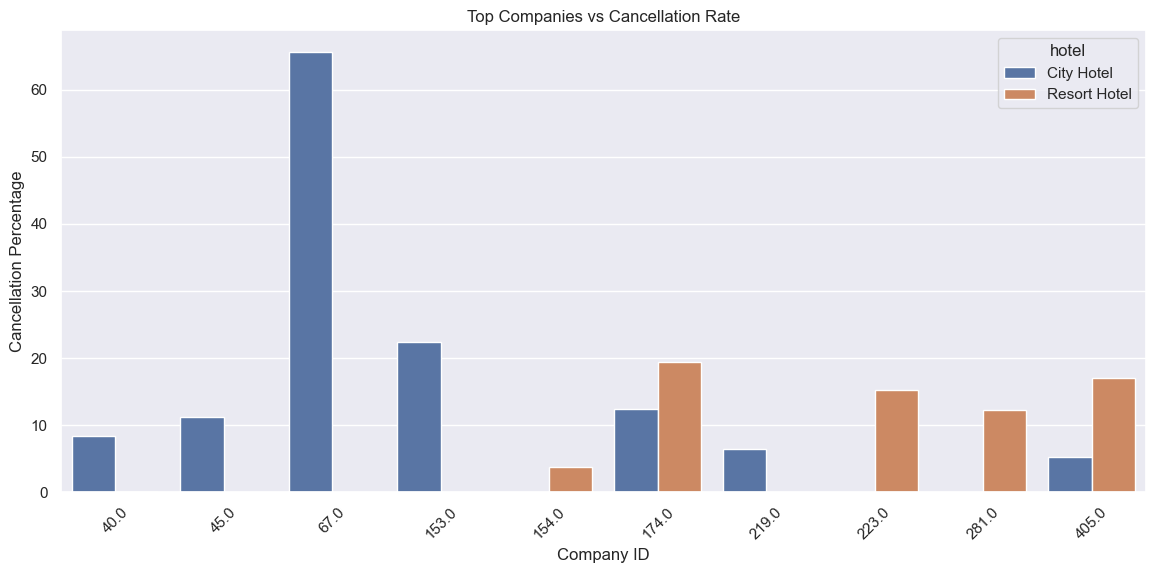

In [165]:
# Top 10 companies
top_companies = df['company'].value_counts().head(10).index

temp = df[df['company'].isin(top_companies)]

company_cancel = pd.crosstab(
    [temp['company'], temp['hotel']],
    temp['is_canceled'],
    normalize='index'
) * 100

company_cancel = company_cancel.reset_index()

plt.figure(figsize=(14,6))

sns.barplot(
    data=company_cancel,
    x='company',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Company ID')
plt.title('Top Companies vs Cancellation Rate')

plt.xticks(rotation=45)

plt.show()

## days_in_waiting_list vs is_canceled

In [168]:
pd.crosstab([df['days_in_waiting_list'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                 0           1
days_in_waiting_list hotel                               
0                    City Hotel     59.466048   40.533952
                     Resort Hotel   72.101495   27.898505
1                    City Hotel     71.428571   28.571429
                     Resort Hotel   80.000000   20.000000
2                    City Hotel     66.666667   33.333333
...                                       ...         ...
236                  City Hotel     82.857143   17.142857
259                  City Hotel    100.000000    0.000000
330                  City Hotel     93.333333    6.666667
379                  City Hotel     40.000000   60.000000
391                  City Hotel      0.000000  100.000000

[159 rows x 2 columns]

The relationship between days_in_waiting_list and is_canceled indicates that most hotel bookings experience little to no waiting period, with the vast majority of reservations having a waiting-list duration of zero days. Among these bookings, City Hotel exhibits substantially higher cancellation rates compared to Resort Hotels, reinforcing the broader trend of greater booking volatility in City Hotels. As waiting-list duration increases, cancellation behavior becomes increasingly irregular, with some waiting periods showing high cancellation percentages while others remain relatively stable. However, these fluctuations are largely influenced by very low booking frequencies at extreme waiting-list values, making isolated percentages less reliable. Overall, the feature suggests that prolonged waiting periods may reflect operational constraints, booking uncertainty, or inventory pressure, which can contribute to cancellation risk in certain cases. Despite its skewed distribution and sparse extreme values, days_in_waiting_list may still provide useful predictive information when transformed or grouped appropriately during feature engineering.

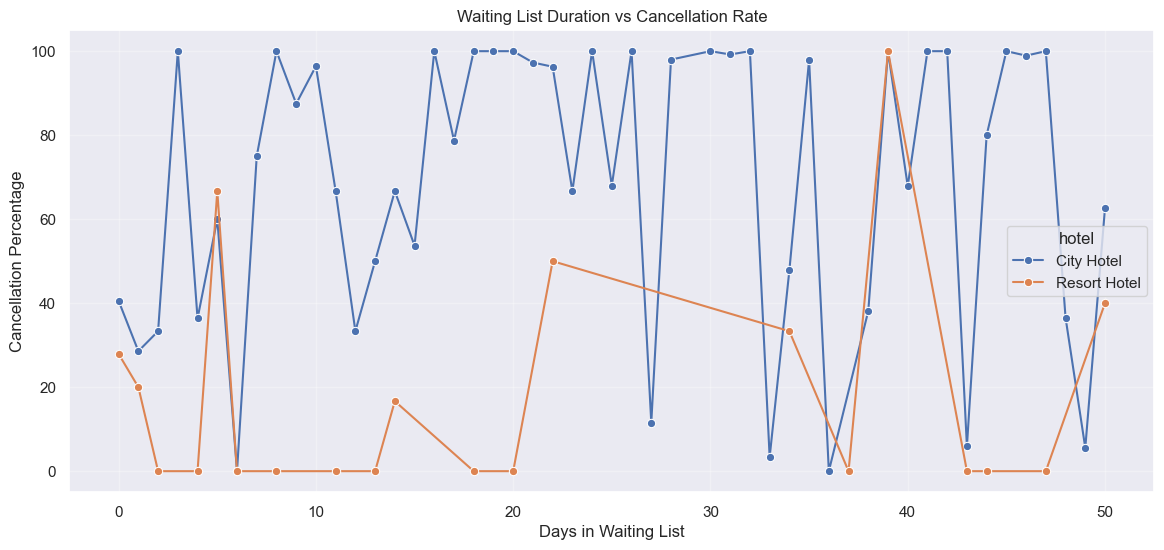

In [171]:
# Limiting extreme values for better readability
temp = df[df['days_in_waiting_list'] <= 50]

waiting_cancel = pd.crosstab(
    [temp['days_in_waiting_list'], temp['hotel']],
    temp['is_canceled'],
    normalize='index'
) * 100

waiting_cancel = waiting_cancel.reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=waiting_cancel,
    x='days_in_waiting_list',
    y=1,
    hue='hotel',
    marker='o'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Days in Waiting List')
plt.title('Waiting List Duration vs Cancellation Rate')

plt.grid(alpha=0.3)

plt.show()

## customer_type vs is_canceled

In [180]:
pd.crosstab([df['customer_type'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                           0          1
customer_type   hotel                             
Contract        City Hotel    51.956522  48.043478
                Resort Hotel  91.159910   8.840090
Group           City Hotel    90.102389   9.897611
                Resort Hotel  89.436620  10.563380
Transient       City Hotel    54.383543  45.616457
                Resort Hotel  68.830481  31.169519
Transient-Party City Hotel    71.903306  28.096694
                Resort Hotel  80.503145  19.496855

The relationship between customer_type and is_canceled reveals clear differences in booking stability across customer segments. Transient customers exhibit the highest cancellation rates in both hotel types, particularly in City Hotel where nearly half of all transient bookings are canceled. This indicates that independent travelers tend to display more flexible and uncertain booking behavior. In contrast, Group customers demonstrate the lowest cancellation rates across both City and Resort Hotels, suggesting stronger commitment and more coordinated travel arrangements. Transient-Party bookings show moderate cancellation behavior, positioned between fully transient and group travelers. The Contract segment presents an interesting contrast: Resort Hotels maintain highly stable contract bookings with very low cancellations, while City Hotels show unusually high cancellation levels for the same category, indicating that contract-based travel behavior differs substantially across hotel types. Overall, customer type emerges as a strong behavioral feature that captures differences in travel intent, booking flexibility, and commitment levels, making it highly valuable for cancellation prediction and customer segmentation.

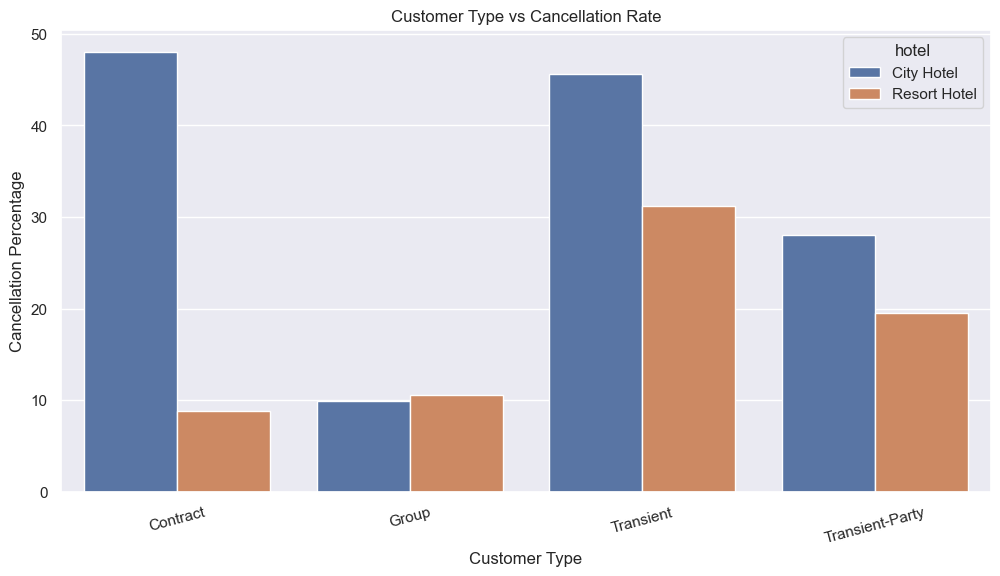

In [183]:
customer_cancel = pd.crosstab(
    [df['customer_type'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

customer_cancel = customer_cancel.reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=customer_cancel,
    x='customer_type',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Customer Type')
plt.title('Customer Type vs Cancellation Rate')

plt.xticks(rotation=15)

plt.show()

In [194]:
df.groupby(['is_canceled','hotel'])['adr'].agg(['mean', 'median', 'std','max'])

mean  median        std     max
is_canceled hotel                                              
0           City Hotel    105.745948    99.9  40.596109   510.0
            Resort Hotel   90.788971    72.0  59.320827   508.0
1           City Hotel    104.687920    99.8  47.478317  5400.0
            Resort Hotel  105.787010    84.0  65.419172   450.0

The relationship between adr (Average Daily Rate) and is_canceled shows notable differences across hotel types. In City Hotel, canceled and non-canceled bookings exhibit very similar average ADR values, indicating that pricing alone has limited influence on cancellation behavior for City Hotels. However, City Hotels maintain consistently high ADR levels overall, reflecting stronger urban demand and premium pricing patterns. In contrast, Resort Hotels display a more pronounced relationship between ADR and cancellations: canceled bookings have substantially higher average and median ADR values compared to non-canceled reservations. This suggests that expensive resort bookings are more cancellation-prone, likely due to seasonal demand fluctuations, advance planning uncertainty, and high-value leisure travel behavior. Additionally, Resort Hotels show considerably higher ADR variability, as reflected by the larger standard deviation, indicating broader pricing dispersion across booking types and travel seasons. Overall, ADR appears to be a stronger cancellation signal for Resort Hotels than for City Hotels and remains an important revenue-related feature for predictive modeling and pricing analysis.sn

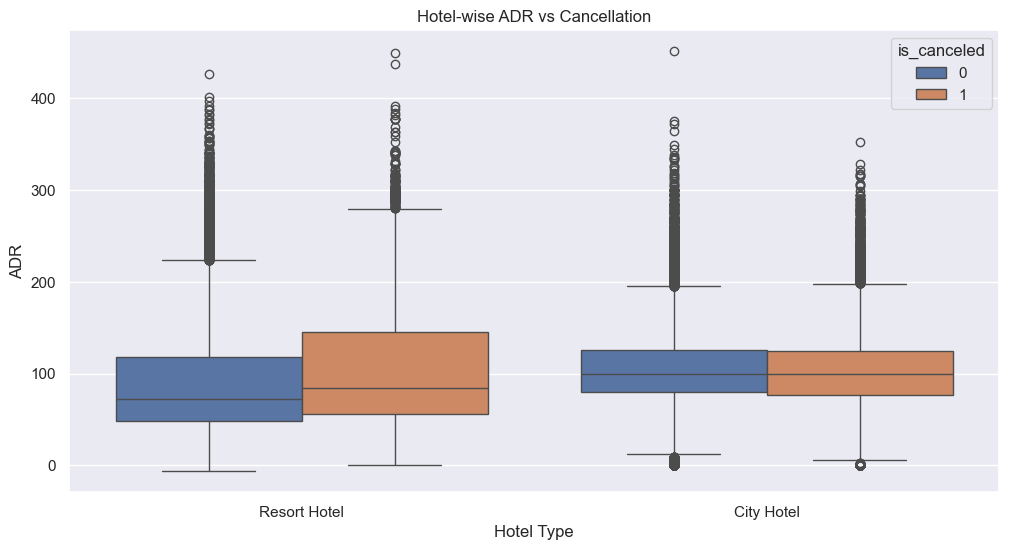

In [190]:
temp = df[df['adr'] < 500]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=temp,
    x='hotel',
    y='adr',
    hue='is_canceled'
)

plt.title('Hotel-wise ADR vs Cancellation')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')

plt.show()

In [196]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'meal_full'],
      dtype='object')

## required_car_parking_spaces vs is_canceled

In [201]:
pd.crosstab([df['required_car_parking_spaces'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                        0          1
required_car_parking_spaces hotel                              
0                           City Hotel     57.234768  42.765232
                            Resort Hotel   67.827596  32.172404
1                           City Hotel    100.000000   0.000000
                            Resort Hotel  100.000000   0.000000
2                           City Hotel    100.000000   0.000000
                            Resort Hotel  100.000000   0.000000
3                           City Hotel    100.000000   0.000000
                            Resort Hotel  100.000000   0.000000
8                           Resort Hotel  100.000000   0.000000

he relationship between required_car_parking_spaces and is_canceled reveals a remarkably strong behavioral pattern in the hotel booking dataset. Bookings with no parking requirement exhibit substantially higher cancellation rates across both hotel types, particularly in City Hotel where cancellations exceed 40%. In contrast, reservations requesting one or more parking spaces show virtually zero cancellation activity in both City and Resort Hotels. This suggests that customers requesting parking are significantly more committed to their travel plans and are less likely to cancel their reservations. Parking requirements may also act as an indirect indicator of serious leisure or family travel, where transportation logistics increase booking commitment. Although higher parking-space counts occur very rarely and are likely influenced by small sample sizes, the overall pattern strongly indicates that parking demand is associated with stable and reliable bookings. Consequently, required_car_parking_spaces emerges as a surprisingly strong predictive feature for cancellation modeling.

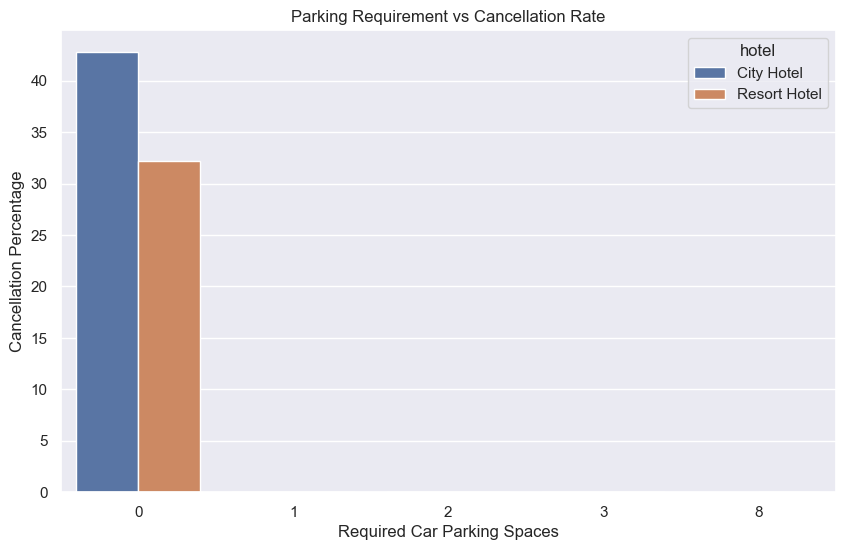

In [204]:
parking_cancel = pd.crosstab(
    [df['required_car_parking_spaces'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

parking_cancel = parking_cancel.reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=parking_cancel,
    x='required_car_parking_spaces',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Required Car Parking Spaces')
plt.title('Parking Requirement vs Cancellation Rate')

plt.show()

## total_of_special_requests vs is_canceled

In [207]:
pd.crosstab([df['total_of_special_requests'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                                     0          1
total_of_special_requests hotel                             
0                         City Hotel    45.075797  54.924203
                          Resort Hotel  67.729529  32.270471
1                         City Hotel    77.959851  22.040149
                          Resort Hotel  78.002710  21.997290
2                         City Hotel    78.641611  21.358389
                          Resort Hotel  76.652165  23.347835
3                         City Hotel    82.356648  17.643352
                          Resort Hotel  81.758242  18.241758
4                         City Hotel    89.393939  10.606061
                          Resort Hotel  89.436620  10.563380
5                         City Hotel    96.153846   3.846154
                          Resort Hotel  92.857143   7.142857

The relationship between total_of_special_requests and is_canceled demonstrates one of the clearest behavioral trends in the hotel booking dataset. Bookings with zero special requests exhibit extremely high cancellation rates, particularly in City Hotel where more than half of such reservations are canceled. However, as the number of special requests increases, cancellation rates decline consistently across both City and Resort Hotels. Customers making multiple special requests appear significantly more committed to their stay, likely because they are actively engaging with the hotel and customizing their reservation experience. This trend is especially strong for bookings with four or more requests, where cancellation rates become very low. The pattern suggests that special requests act as a strong proxy for customer intent, travel seriousness, and booking engagement. Overall, total_of_special_requests emerges as one of the most powerful behavioral predictors of booking stability and cancellation risk in the dataset.

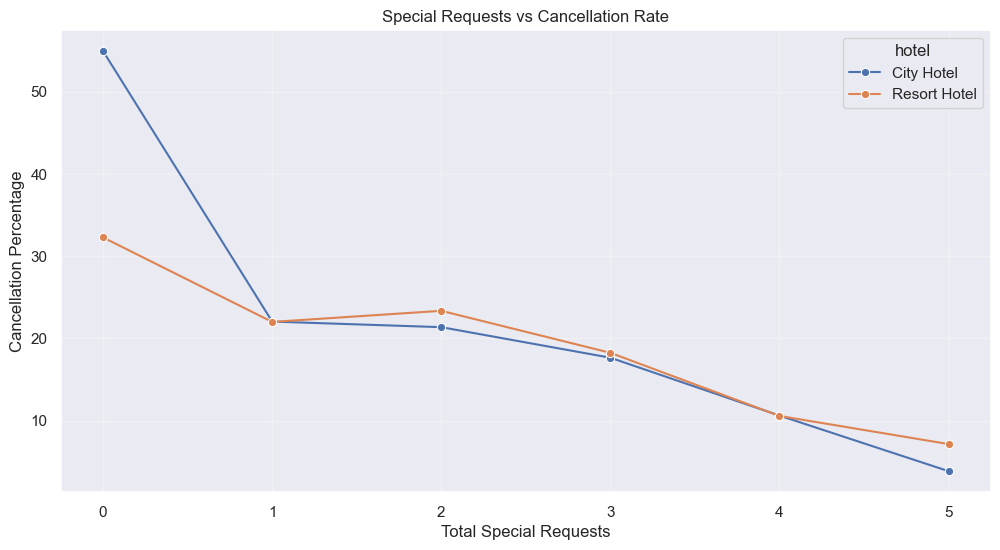

In [210]:
special_request_cancel = pd.crosstab(
    [df['total_of_special_requests'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

special_request_cancel = special_request_cancel.reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=special_request_cancel,
    x='total_of_special_requests',
    y=1,
    hue='hotel',
    marker='o'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Total Special Requests')
plt.title('Special Requests vs Cancellation Rate')

plt.grid(alpha=0.3)

plt.show()

## reservation_status vs is_canceled

In [213]:
pd.crosstab([df['reservation_status'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                          0      1
reservation_status hotel                     
Canceled           City Hotel      0.0  100.0
                   Resort Hotel    0.0  100.0
Check-Out          City Hotel    100.0    0.0
                   Resort Hotel  100.0    0.0
No-Show            City Hotel      0.0  100.0
                   Resort Hotel    0.0  100.0

The relationship between reservation_status and is_canceled shows a perfectly deterministic pattern in the hotel booking dataset. Reservations marked as Canceled or No-Show exhibit a 100% cancellation rate across both City Hotel and Resort Hotels, while bookings with Check-Out status show zero cancellations. This occurs because reservation_status is directly generated from the final outcome of the booking process and therefore contains explicit information about whether the reservation was canceled or completed. As a result, the feature introduces severe target leakage and should not be used as a predictive feature during machine learning model training. Although it provides strong descriptive insight into booking outcomes, its direct dependency on the target variable makes it unsuitable for predictive modeling. Overall, reservation_status is best treated as a post-booking operational variable rather than an input feature for cancellation prediction.

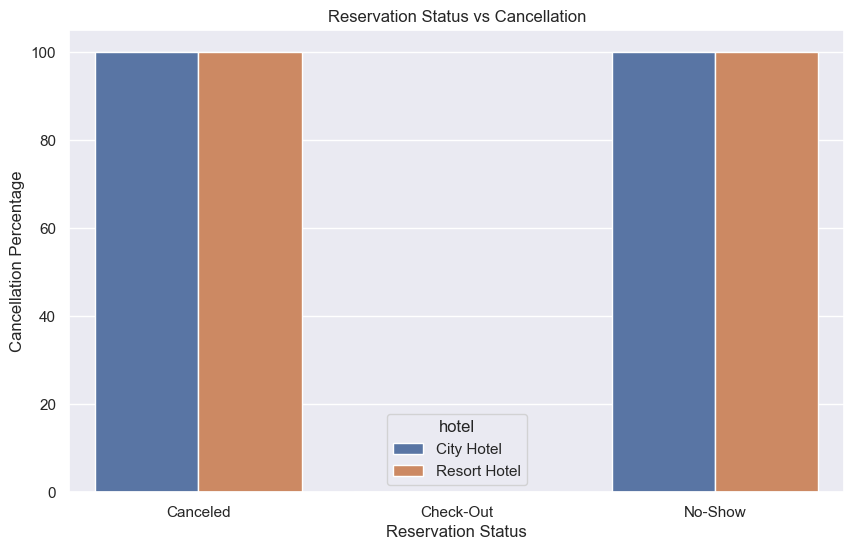

In [216]:
reservation_status_cancel = pd.crosstab(
    [df['reservation_status'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

reservation_status_cancel = reservation_status_cancel.reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=reservation_status_cancel,
    x='reservation_status',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Reservation Status')
plt.title('Reservation Status vs Cancellation')

plt.show()

## reservation_status_date vs is_canceled

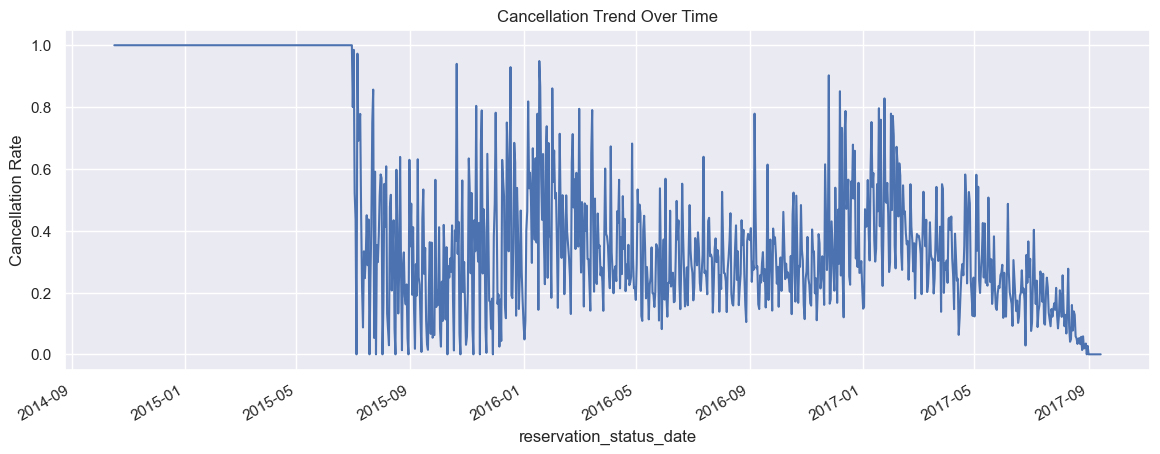

In [222]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

cancel_trend = df.groupby(
    'reservation_status_date'
)['is_canceled'].mean()

cancel_trend.plot(figsize=(14,5))

plt.title('Cancellation Trend Over Time')
plt.ylabel('Cancellation Rate')

plt.show()

## meal_full vs is_canceled

In [232]:
pd.crosstab([df['meal_full'],df['hotel']],df['is_canceled'],normalize='index')*100

is_canceled                           0          1
meal_full       hotel                             
Bed & Breakfast City Hotel    57.199262  42.800738
                Resort Hotel  73.861023  26.138977
Full Board      City Hotel    20.454545  79.545455
                Resort Hotel  41.246684  58.753316
Half Board      City Hotel    62.022752  37.977248
                Resort Hotel  68.344519  31.655481
Self Catering   City Hotel    62.485801  37.514199
                Resort Hotel  96.511628   3.488372
Undefined       Resort Hotel  75.534645  24.465355

The relationship between meal_full and is_canceled reveals meaningful differences in booking stability across meal plan selections. Bookings with Bed & Breakfast, the most common meal category, show relatively high cancellation rates, particularly in City Hotel where cancellations exceed 40%. Full Board reservations exhibit the highest cancellation tendencies across both hotel types, suggesting that premium or fully packaged bookings may be more sensitive to changes in travel plans or pricing. Half Board and Self Catering bookings display comparatively more stable behavior, especially in Resort Hotels where self-catering reservations show extremely low cancellation rates, indicating stronger commitment among leisure travelers managing longer stays independently. The Undefined category remains relatively stable but likely reflects operational or data-quality inconsistencies rather than meaningful customer behavior. Overall, meal choice appears to capture aspects of travel intent, booking value, and customer planning behavior, making it a moderately informative feature for understanding cancellation patterns and customer segmentation.

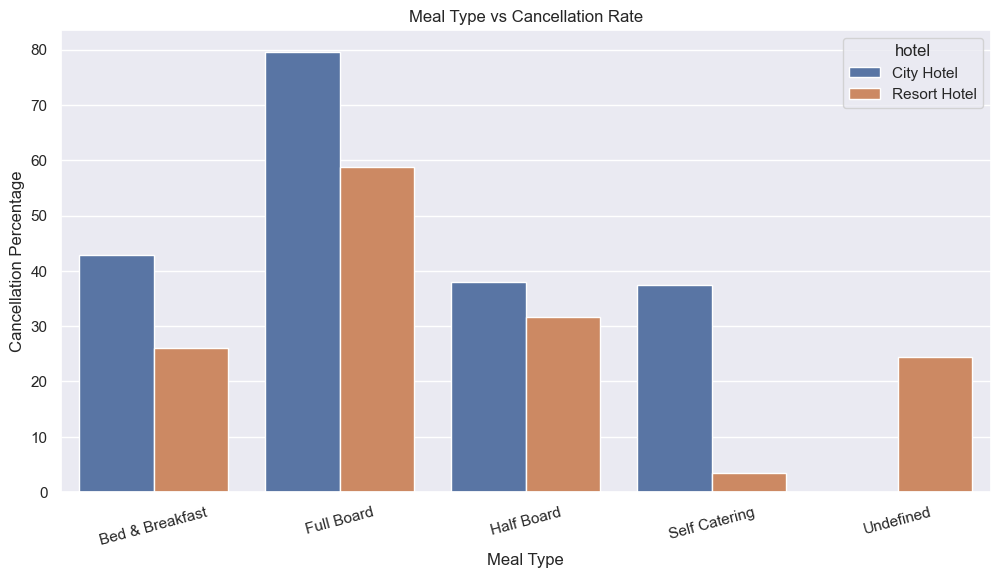

In [235]:
meal_cancel = pd.crosstab(
    [df['meal_full'], df['hotel']],
    df['is_canceled'],
    normalize='index'
) * 100

meal_cancel = meal_cancel.reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=meal_cancel,
    x='meal_full',
    y=1,
    hue='hotel'
)

plt.ylabel('Cancellation Percentage')
plt.xlabel('Meal Type')
plt.title('Meal Type vs Cancellation Rate')

plt.xticks(rotation=15)

plt.show()

# Hotel Booking Cancellation Analysis — Comprehensive Bivariate Analysis Summary

The bivariate analysis of the hotel booking dataset provided extensive insight into the behavioral, operational, demographic, and pricing-related factors influencing reservation cancellations across City Hotel and Resort Hotels. Building upon the findings from the univariate analysis, the study revealed that cancellation behavior is primarily driven by booking intent, customer engagement, distribution strategy, pricing dynamics, and operational characteristics rather than purely demographic attributes.

The earlier univariate analysis established several foundational patterns within the dataset. The booking ecosystem was heavily dominated by City Hotels, OTA-driven reservations, transient customers, short-duration stays, and highly skewed lead times. Features such as ADR, booking changes, waiting-list duration, special requests, agent IDs, and distribution channels displayed strong variability and non-uniform distributions, indicating diverse booking behaviors and customer segments. The dataset also demonstrated clear operational complexity through dynamic pricing, room reallocations, intermediary dependence, and seasonal demand concentration.

The bivariate analysis significantly expanded these findings by identifying direct relationships between individual features and cancellation outcomes. Behavioral and transactional variables consistently emerged as the strongest cancellation indicators. Long lead times showed substantially higher cancellation probability, confirming that customers booking far in advance are more likely to modify or abandon travel plans. Deposit policies exhibited extremely strong predictive power, with non-refundable bookings strongly associated with cancellation-heavy segments, reflecting hotel-side risk management strategies and booking conditions.

Customer engagement indicators such as booking changes, special requests, and parking requirements demonstrated remarkably stabilizing effects on reservations. Customers actively interacting with their bookings — by modifying reservations, requesting parking spaces, or adding multiple special requests — were significantly less likely to cancel, indicating stronger travel commitment and booking intent.

The analysis of customer demographics and occupancy-related features revealed comparatively weaker relationships with cancellation behavior. Variables such as `adults`, `children`, `babies`, `stays_in_week_nights`, and `stays_in_weekend_nights` displayed only modest and inconsistent predictive relationships compared to behavioral and operational features. The dataset was dominated by couple-based travel patterns involving two adults, while family-oriented bookings with children or babies represented a smaller share of reservations. Although family bookings occasionally appeared slightly more stable, especially in Resort Hotels, demographic composition alone did not strongly influence cancellation probability. Similarly, stay-duration variables reflected dominant short-stay travel behavior but showed limited standalone predictive importance.

Distribution-channel analysis revealed that OTA and intermediary-driven reservations contributed disproportionately to cancellations, while repeat guests and corporate/company bookings demonstrated significantly greater stability and reliability. Customer segmentation analysis further reinforced these findings: transient customers consistently exhibited the highest cancellation risk, whereas group travelers, contract bookings, and company-based reservations displayed more predictable booking behavior.

Pricing analysis through ADR revealed that higher-priced reservations, particularly in Resort Hotels, were more vulnerable to cancellation. This pattern reflected the uncertainty associated with premium leisure travel, seasonal demand fluctuations, and dynamic pricing strategies. Meal-plan analysis also suggested that fully packaged bookings such as Full Board reservations exhibited elevated cancellation tendencies compared to more flexible meal arrangements.

The analysis additionally highlighted strong structural differences between hotel types. City Hotels consistently experienced higher cancellation rates across most features, suggesting greater exposure to flexible urban travel behavior, business uncertainty, and OTA-driven volatility. Resort Hotels generally displayed more stable booking patterns but showed stronger sensitivity to pricing-related features such as ADR, meal plans, and seasonal demand.

---

# Key Behavioral Patterns Detected

Several highly significant behavioral and operational patterns emerged consistently throughout the analysis:

* Customers exhibiting higher engagement levels — through booking modifications, parking requests, and multiple special requests — were significantly less likely to cancel.
* Reservations with zero interaction indicators consistently displayed the highest cancellation risk.
* Long advance bookings were substantially more volatile than short-term reservations.
* OTA and intermediary-driven bookings generated considerably higher cancellation exposure compared to direct, corporate, or repeat-customer reservations.
* Repeat guests demonstrated exceptionally strong booking reliability, indicating clear customer loyalty effects.
* City Hotel bookings consistently showed greater cancellation volatility than Resort Hotel reservations across nearly all major features.
* Group and company-based bookings behaved far more predictably than transient independent travelers.
* High-value resort reservations exhibited stronger pricing sensitivity and higher cancellation probability.
* Demographic variables such as adults, children, babies, and stay durations showed relatively weak predictive relationships compared to behavioral and operational features.
* Customers making multiple special requests or requiring parking spaces demonstrated exceptionally strong booking commitment.

---

# Major Trends Observed During Analysis

The analysis revealed several important operational and market-level trends:

### 1. Strong OTA Dependence

The dataset showed heavy reliance on Online Travel Agencies and travel intermediaries, making cancellation behavior highly sensitive to third-party booking ecosystems.

### 2. Dynamic Pricing Environment

ADR distributions demonstrated strong evidence of dynamic pricing strategies influenced by seasonality, room categories, customer segments, and demand fluctuations.

### 3. Seasonal Demand Concentration

Booking activity peaked during high-tourism periods, particularly in summer months, with Resort Hotels exhibiting stronger leisure-season demand patterns.

### 4. Low Customer Retention

Repeat guests represented only a small fraction of total reservations, suggesting a predominantly tourism-driven and short-term customer base.

### 5. Operational Reallocation Behavior

Assigned room types frequently differed from reserved room types, indicating active inventory optimization and operational flexibility.

### 6. Behavioral Signals Strongly Outperform Demographics

Behavioral, transactional, and operational features consistently outperformed demographic variables in predictive relevance for cancellation behavior.

### 7. Strong Urban vs Leisure Travel Divide

City Hotels exhibited highly flexible and cancellation-prone booking behavior, while Resort Hotels reflected comparatively stable but price-sensitive leisure travel patterns.

---

# Most Important Features for Building a Classification Model

The following features emerged as the strongest predictors for hotel booking cancellation classification:

| Feature                                     | Significance                                                                                        |
| ------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| `lead_time`                                 | Strongest behavioral predictor; long advance bookings showed significantly higher cancellation risk |
| `deposit_type`                              | Extremely high predictive power reflecting customer commitment and hotel risk policies              |
| `market_segment`                            | Captures booking intent and customer acquisition channel behavior                                   |
| `distribution_channel`                      | OTA and TA/TO channels strongly associated with cancellation-heavy reservations                     |
| `total_of_special_requests`                 | Strong inverse relationship with cancellation; engaged customers rarely cancel                      |
| `required_car_parking_spaces`               | Highly stable bookings associated with parking requirements                                         |
| `repeated_guest`                            | Strong loyalty signal; repeat customers rarely cancel                                               |
| `previous_cancellations`                    | Direct indicator of habitual cancellation behavior                                                  |
| `previous_bookings_not_canceled`            | Strong customer reliability and trustworthiness signal                                              |
| `customer_type`                             | Transient customers showed substantially higher cancellation probability                            |
| `adr`                                       | Important pricing and revenue-based cancellation indicator                                          |
| `booking_changes`                           | Reservation modifications strongly associated with booking commitment                               |
| `agent`                                     | Major intermediary behavior differences contribute to cancellation variability                      |
| `company`                                   | Corporate bookings generally more stable and reliable                                               |
| `meal_full`                                 | Captures travel style and booking-package characteristics                                           |
| `reserved_room_type` & `assigned_room_type` | Reflect operational allocation behavior and booking expectations                                    |

---

# Features Recommended for Removal

Certain features should be excluded from predictive modeling due to leakage, redundancy, or operational irrelevance:

| Feature                      | Reason for Removal                                                     |
| ---------------------------- | ---------------------------------------------------------------------- |
| `reservation_status`         | Direct target leakage; fully determined by booking outcome             |
| `reservation_status_date`    | Severe target leakage; reflects post-outcome operational status timing |
| Raw `agent` IDs (optional)   | High cardinality; may require encoding/grouping before use             |
| Raw `company` IDs (optional) | High cardinality with sparse categories                                |
| Extremely sparse categories  | Low-frequency values may introduce noise and overfitting               |

---

# Recommended Feature Engineering Strategies

Several strong feature-engineering opportunities emerged during the analysis:

### Behavioral Features

* Create engagement scores using:

  * special requests,
  * booking changes,
  * parking requirements,
  * repeat-guest behavior.

### Time-Based Features

* Extract:

  * booking season,
  * arrival quarter,
  * peak/off-season indicators,
  * weekday/weekend stay ratios.

### Lead Time Transformations

* Bin lead times into:

  * short,
  * medium,
  * long-term booking groups.

### ADR Engineering

* Create:

  * ADR bins,
  * hotel-wise normalized ADR,
  * seasonal pricing indicators.

### High-Cardinality Encoding

For `agent`, `company`, and `country`:

* frequency encoding,
* target encoding,
* grouping rare categories,
* top-category consolidation.

### Room Allocation Features

* Create room mismatch indicators:

  * reserved vs assigned room differences,
  * upgrade/downgrade flags.

### Customer Reliability Scores

Combine:

* previous cancellations,
* previous successful bookings,
* repeat guest behavior,
* booking modifications.

### Family & Occupancy Features

* Create:

  * total guests feature (`adults + children + babies`),
  * family vs non-family booking indicators,
  * occupancy-density metrics.

---

# Final Conclusion

The hotel booking cancellation analysis revealed that reservation cancellations are fundamentally driven by customer behavior, booking intent, distribution-channel dynamics, operational strategies, and pricing conditions rather than simple demographic characteristics. Features capturing engagement, commitment, loyalty, booking flexibility, and intermediary behavior consistently outperformed static customer attributes in predictive importance. The dataset demonstrated strong evidence of OTA-driven volatility, dynamic pricing behavior, seasonal demand effects, operational complexity, and distinct travel patterns between urban and leisure hotel environments.

From a machine learning perspective, the dataset is exceptionally well-suited for classification modeling due to the presence of numerous high-signal behavioral features, clear cancellation patterns, and meaningful interactions between customer behavior and hotel operations. With appropriate preprocessing, leakage removal, feature engineering, encoding strategies, and imbalance handling, the dataset has strong potential for building highly accurate hotel cancellation prediction systems capable of supporting revenue optimization, operational planning, customer segmentation, customer-retention strategies, and proactive risk-management decision-making.
